## 1  Introduction

### 1.1  Research background

Sport and recreation can involve injuries whose patterns differ across age and activity. Rui, Ashman and Akinseye (2019) found age-related differences in injured body regions among patients aged 5–24 using a different US emergency-department survey. Their restricted age range motivates a wider lifespan comparison, although their case definition prevents direct numerical comparison with this study. NEISS provides a common surveillance framework across ages.

The analysis compares recorded presentations across ages, then examines the body regions, diagnoses, activities and care outcomes involved. It describes patterns in these records; it does not predict whether an individual will be injured.

Core presentations peak at age 14. Head and face injuries account for 52% before age five but 13% at ages 45–54, while trunk and spine injuries become more prominent in older groups. Diagnosis patterns also change with age. Activities have distinct age profiles, and care escalation rises across supported adolescent and adult groups; unreliable estimates limit conclusions at the oldest ages.

### 1.2  What the outcome is, and what it is not

The unit of observation is a sport- and recreation-product-associated emergency-department presentation: a patient treated at a sampled Emergency Department (ED) whose record carries a product code that this project's taxonomy classifies as sport or recreation. Two limits follow, and they constrain every claim made here.

Product association is not participation. A record coded to bicycles may be a child struck while riding, an adult commuting, or someone who tripped over a stationary bicycle. The product was involved; the person was not necessarily playing a sport.

There is no participation denominator in these files: they do not tell us how many people took part in each activity or for how long. The analysis therefore estimates presentation totals and percentages among presentations. It does not estimate the chance of injury for a participant. The denominator for each percentage is stated in the relevant section.

### 1.3  Research objectives and questions

The objectives are to describe age and sex patterns in presentations and how their clinical composition varies, and to assess how activity definitions and reliability screening affect those conclusions. Five research questions address these objectives.

|  | Research question | Figure |
| --- | --- | --- |
| RQ1 | How are Core sport-associated ED presentations distributed across age and recorded sex? | 2 |
| RQ2 | Does the anatomical distribution of injury change across the lifespan? | 3 |
| RQ3 | Does the diagnostic character of injury change across the lifespan? | 4 |
| RQ4 | Do individual activities have distinguishable age signatures? | 5, 6 |
| RQ5 | How does escalation beyond treat-and-release vary across age groups? | 7 |

## 2  Data source

NEISS is a stratified probability sample of US hospital emergency departments with at least six beds and a 24-hour ED, run by the Consumer Product Safety Commission since 1972. Trained coders extract eligible records and code demographic, injury, product and narrative fields (CPSC, 2020).

NEISS exists to support product regulation, not clinical epidemiology, and that shapes the data. Body part and diagnosis use coarse fixed lists. However, named sporting activities can be coded even without equipment involvement (CPSC, 2020, p. 29); equipment-free sport injuries are not automatically absent. Coding practice also moves: six fields (Body_Part_2, Diagnosis_2, Product_3, Hispanic, Alcohol, Drug) were added on 1 January 2019. All six are excluded from the core analysis, because including them would let later years qualify on evidence that earlier years could not carry.

Each record carries Stratum (hospital size class), PSU (the sampled hospital) and Weight (inverse selection probability, ratio-adjusted to national ED visit totals). The primary sampling unit is the hospital, not the patient, so variance is approximated between hospitals within strata. The new sample first contributed national estimates in 2024; CPSC backcast its historical series using an overlap comparison (Schroeder, 2026). This analysis does not backcast or assume independent annual samples.

NEISS public-use files are freely accessible and de-identified. Raw narratives are omitted from the shared analytical files to minimise disclosure. De-identification is not a guarantee against re-identification or an institutional ethics exemption. Race is not analysed, and its completeness and recording process would require separate evaluation.

The project uses 2016–2025. This limits the time span over which activity participation and recording practices may differ, but does not make the years directly interchangeable. The 2020 decline and the 2024 sample change are examined later through sensitivity analyses.

The files contain all eligible NEISS product-associated records, not just sport records. The analysis first checks those source records, then applies the project’s product classification and cleaning rules. Core is the main study cohort; Extended includes Core plus selected recreational categories. These are overlapping cohorts, so their counts must not be added together.

### Libraries and project files

The code loads the libraries used to read the data, calculate estimates and draw the figures. It also sets the project folders and records library versions so the analysis can be reproduced.


In [1]:
import sys
import os
from pathlib import Path
import itertools
import json
import platform
import importlib.metadata as metadata

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (PROJECT_ROOT / "src/neiss.py").is_file():
    raise FileNotFoundError("Open the draft project folder or its notebooks folder before running.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from IPython.display import display
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import neiss
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")

YEARS = neiss.YEARS
FIGURES = PROJECT_ROOT / "figures"
TABLES = PROJECT_ROOT / "tables"
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
VERSIONS = {"python": platform.python_version()}
VERSIONS.update({p: metadata.version(p) for p in ["numpy", "pandas", "matplotlib", "scipy"]})
display(pd.Series(VERSIONS, name="actual_runtime"))

python        3.12.14
numpy           2.5.3
pandas          3.0.1
matplotlib     3.11.1
scipy          1.18.1
Name: actual_runtime, dtype: str

## 3  Data exploration and preparation

### Source files and scope of the checks

The annual files cover 2016–2025. Before selecting sport and recreation records, the following cells examine file structure, recorded values, missing information, duplicates and survey weights. Reading a file and converting values temporarily for a diagnostic check does not remove records from the study.

The output states whether this run reads the annual source files or uses saved summaries previously calculated from them. Saved summaries are checked against source-file, dictionary and calculation fingerprints. They reproduce the recorded checks but do not constitute a fresh inspection of the source files. A partially available set of annual files raises an error rather than silently omitting years.

In [2]:
# Raw Exploratory Data Analysis 1
import raw_eda
local_raw_config = PROJECT_ROOT / ".runtime/raw_source_dir.txt"
local_raw_default = (local_raw_config.read_text(encoding="utf-8-sig").strip()
                     if local_raw_config.exists() else PROJECT_ROOT / "data/source")
RAW_SOURCE_DIR = Path(os.environ.get("NEISS_RAW_DIR", local_raw_default))
RAW_EDA_MODE = os.environ.get("NEISS_EDA_MODE", "auto")  # auto / raw / cached
raw_paths = [RAW_SOURCE_DIR / f"neiss{year}.tsv" for year in YEARS]
raw_present = [p.is_file() for p in raw_paths]
if RAW_EDA_MODE not in {"auto", "raw", "cached"}:
    raise ValueError("Choose auto, raw or cached for RAW_EDA_MODE.")
if RAW_EDA_MODE == "raw" and not all(raw_present):
    raise FileNotFoundError("Raw mode needs all ten annual TSVs in RAW_SOURCE_DIR.")
if RAW_EDA_MODE == "auto" and any(raw_present) and not all(raw_present):
    raise FileNotFoundError("Partial raw window: supply all ten files or explicitly choose cached mode.")
READ_RAW_EDA = RAW_EDA_MODE == "raw" or (RAW_EDA_MODE == "auto" and all(raw_present))
print("RAW DATA EXPLORATION: before cohort cleaning")
print("Mode:", "reading all ten raw annual files" if READ_RAW_EDA else
      "verified saved RAW profiles; annual source files are not being read this run")
# Cached profiles were computed from raw records, never from the cleaned cohort.
# Raw parsing necessarily checks record width first; rejected fragments are counted.
# Source files and clinical narratives are never modified or displayed.


RAW DATA EXPLORATION: before cohort cleaning
Mode: verified saved RAW profiles; annual source files are not being read this run


### File structure and record integrity

Each source file is expected to have 25 fields. They describe the case identifier, treatment date, age, recorded sex, clinical codes, associated products, survey design and narratives.

The next output counts parsed rows by year, records the encoding used and identifies malformed fragments. It checks both identical rows and repeated case identifiers within each year. Those checks answer different questions: repeated identifiers could contain conflicting information even when the whole rows differ. An identifier collision is investigated; the code does not simply keep the first copy.

Dates must belong to the annual file’s year. Survey design fields must be usable before national estimates can be calculated. The values below describe all parsed source records, before the sport/recreation selection.

In [3]:
# RAW Exploratory Data Analysis 2 - One year at a time.
if READ_RAW_EDA:
    annual_rows, field_rows, code_rows, weight_rows, age_rows, flow_rows = [], [], [], [], [], []
    source_hashes = {}
    candidate_core, candidate_ext, _, _ = neiss.taxonomy()
    coded_fields = {"Sex": {0: "Unknown", 1: "Male", 2: "Female"}}
    for field, dictionary_name in [("Body_Part", "body_parts"),
                                    ("Diagnosis", "diagnoses"),
                                    ("Disposition", "dispositions")]:
        coded_fields[field] = neiss.dictionary(dictionary_name).set_index("code").official_label.to_dict()
    for year, source_path in zip(YEARS, raw_paths):
        print(f"Exploring raw {year} ...", flush=True)
        raw, encoding, rejected = neiss.read_raw(source_path)
        source_hashes[source_path.name] = neiss.sha256(source_path)
        # Keep raw strings unchanged; numeric/date views below are diagnostics only.
        numeric_fields = ["Age", "Weight", "PSU", "Sex", "Body_Part", "Diagnosis",
                          "Disposition", "Product_1", "Product_2", "Product_3"]
        numeric = {name: pd.to_numeric(raw[name], errors="coerce") for name in numeric_fields}
        dates = pd.to_datetime(raw.Treatment_Date, format="%m/%d/%Y", errors="coerce")
        blank_ids = raw.CPSC_Case_Number.str.strip().eq("")
        duplicate_ids = raw.CPSC_Case_Number.loc[~blank_ids].duplicated(keep=False)
        age, weight = numeric["Age"], numeric["Weight"]
        decoded_age = neiss.decode_age(age)
        valid_design = (np.isfinite(weight) & weight.gt(0)
                        & np.isfinite(numeric["PSU"]) & numeric["PSU"].gt(0)
                        & numeric["PSU"].mod(1).eq(0) & raw.Stratum.str.strip().isin(neiss.STRATA))
        valid_date = dates.dt.year.eq(year)
        candidate = numeric["Product_1"].isin(candidate_ext) | numeric["Product_2"].isin(candidate_ext)
        annual_rows.append({"year": year, "rows": len(raw), "columns": len(raw.columns),
            "encoding": encoding, "rejected_fragments": len(rejected),
            "blank_case_ids": int(blank_ids.sum()), "duplicate_id_rows": int(duplicate_ids.sum()),
            "exact_duplicate_rows": int(raw.duplicated().sum()),
            "invalid_date_or_year": int((~valid_date).sum()),
            "unknown_age_code_0": int(age.eq(0).sum()),
            "other_invalid_age": int((decoded_age.isna() & ~age.eq(0)).sum()),
            "infant_month_codes": int((age.between(201, 223) & age.mod(1).eq(0)).sum()),
            "zero_weight": int(weight.eq(0).sum()), "negative_weight": int(weight.lt(0).sum()),
            "nonfinite_weight": int((~np.isfinite(weight)).sum()),
            "invalid_design_rows": int((~valid_design).sum()),
            "observed_psus": int(numeric["PSU"].loc[valid_design].nunique()),
            "raw_weight_sum": float(weight.loc[np.isfinite(weight)].sum())})
        for name in raw.columns:
            blank = raw[name].str.strip().eq("")
            field_rows.append({"year": year, "field": name, "rows": len(raw),
                "loaded_dtype": str(raw[name].dtype), "blank_n": int(blank.sum()),
                "blank_percent": 100 * blank.mean(),
                "numeric_parse_failure_n": int((numeric[name].isna() & ~blank).sum())
                    if name in numeric else np.nan})
        for field, labels in coded_fields.items():
            counts = raw[field].value_counts(dropna=False)
            for code, count in counts.items():
                number = pd.to_numeric(code, errors="coerce")
                code_rows.append({"year": year, "field": field, "raw_code": code or "<blank>",
                    "label": labels.get(number, "UNMAPPED / blank"), "n": int(count)})
        finite_weight = weight.loc[np.isfinite(weight)]
        weight_rows.append({"year": year, "mean": finite_weight.mean(),
            **{label: finite_weight.quantile(q) for label, q in
               [("min", 0), ("p01", .01), ("p25", .25), ("median", .5),
                ("p75", .75), ("p99", .99), ("max", 1)]}})
        for code, count in raw.Age.value_counts(dropna=False).items():
            age_rows.append({"year": year, "raw_age_code": code or "<blank>", "n": int(count)})
        # Preview sequential cleaning impact without changing or exporting any cohort.
        stages = [("All parsed raw records", pd.Series(True, index=raw.index)),
                  ("Qualifying P1 or P2", candidate),
                  ("Then valid survey design", candidate & valid_design),
                  ("Then known valid age", candidate & valid_design & decoded_age.notna()),
                  ("Then valid treatment year", candidate & valid_design & decoded_age.notna() & valid_date)]
        previous = len(raw)
        for stage, mask in stages:
            count = int(mask.sum())
            flow_rows.append({"year": year, "stage": stage, "remaining_n": count,
                              "removed_at_step": previous-count})
            previous = count
        final_mask = stages[-1][1]
        core_mask = numeric["Product_1"].isin(candidate_core) | numeric["Product_2"].isin(candidate_core)
        flow_rows.append({"year": year, "stage": "Core subset of final Extended",
                          "remaining_n": int((final_mask & core_mask).sum()),
                          "removed_at_step": int((final_mask & ~core_mask).sum())})
        del raw, numeric
    raw_profiles = {name: pd.DataFrame(rows) for name, rows in zip(raw_eda.TABLE_NAMES,
        [annual_rows, field_rows, code_rows, weight_rows, age_rows, flow_rows])}
    raw_eda.save_profiles(PROJECT_ROOT, raw_profiles, source_hashes)
else:
    raw_profiles = raw_eda.load_profiles(PROJECT_ROOT)
raw_overview = raw_profiles["annual"]
display(raw_overview)
print("Duplicate counts are within-year diagnostics, not automatic deletion instructions.")

,year,rows,columns,encoding,rejected_fragments,blank_case_ids,duplicate_id_rows,exact_duplicate_rows,invalid_date_or_year,unknown_age_code_0,other_invalid_age,infant_month_codes,zero_weight,negative_weight,nonfinite_weight,invalid_design_rows,observed_psus,raw_weight_sum
0,2016,375196,25,utf-8,0,0,0,0,0,49,0,22572,0,0,0,0,84,1.431940e+07
1,2017,386905,25,cp1252,2,0,0,0,0,20,0,22818,0,0,0,0,89,1.472770e+07
2,2018,361666,25,utf-8,2,0,0,0,0,18,0,21264,0,0,0,0,88,1.395916e+07
3,2019,358714,25,utf-8,2,0,0,0,0,37,0,21505,0,0,0,0,84,1.346429e+07
4,2020,309370,25,utf-8,0,0,0,0,0,28,0,20753,0,0,0,0,82,1.099408e+07
5,2021,340440,25,utf-8,4,0,0,0,0,29,0,21365,0,0,0,0,80,1.173807e+07
6,2022,323343,25,utf-8,0,0,0,0,0,33,0,20176,0,0,0,0,78,1.266303e+07
7,2023,338259,25,utf-8,6,0,0,0,0,23,0,19321,0,0,0,0,78,1.274007e+07
8,2024,361672,25,utf-8,0,0,0,0,0,29,0,21952,0,0,0,0,77,1.506898e+07
9,2025,410201,25,utf-8,0,0,0,0,0,45,0,24339,0,0,0,0,77,1.648541e+07


Duplicate counts are within-year diagnostics, not automatic deletion instructions.


**What the file checks found.** The ten source files contain 3,565,766 structurally valid rows. The reader rejected 16 malformed input fragments. A fragment is not necessarily a complete presentation, so this is not described as 16 patients removed. The 2017 file required cp1252 decoding after UTF-8 failed.

No repeated case identifiers within years or identical rows were found in the parsed data. No invalid treatment dates or mismatched source years were found. These are findings from the checks, not assumptions made before reading the data. The annual evidence is saved in `data/exploration/annual.csv`.

### Blank fields and coded values

A blank cell and an explicit unknown code are counted separately. For example, Age=0 means unknown age, whereas Body_Part=0 is a valid category for internal injury. Product_2=0 indicates that there is no second associated product. Replacing every zero with a missing value would therefore damage the data.

The first table shows the loaded field types and blank counts. The code-frequency table then shows the actual recorded categories and their official meanings. The heatmap expresses blank counts as percentages of all parsed records in each year, making years of different sizes comparable.

Fields introduced in 2019 are unavailable earlier, sometimes represented by a placeholder code rather than a blank. Their absence is a change in the recording system. Other text fields are conditional: for example, an “other diagnosis” description need not be completed for every diagnosis. Neither situation justifies deleting an otherwise usable record or filling every blank.

,loaded_dtype,blank_n,numeric_parse_failure_n
field,,,
CPSC_Case_Number,str,0,NaN
Treatment_Date,str,0,NaN
Age,str,0,0.0
Sex,str,0,0.0
Race,str,0,NaN
Other_Race,str,3408777,NaN
Hispanic,str,1123767,NaN
Body_Part,str,0,0.0
Diagnosis,str,0,0.0


,field,raw_code,label,n
0,Body_Part,0,INTERNAL,42227
1,Body_Part,30,SHOULDER,137016
2,Body_Part,31,UPPER TRUNK,203711
3,Body_Part,32,ELBOW,82861
4,Body_Part,33,LOWER ARM,121504
...,...,...,...,...
61,Disposition,8,"FATALITY INCL. DOA, DIED IN ER",2724
62,Disposition,9,"UNKNOWN, NOT STATED",132
63,Sex,0,Unknown,744
64,Sex,1,Male,1928651


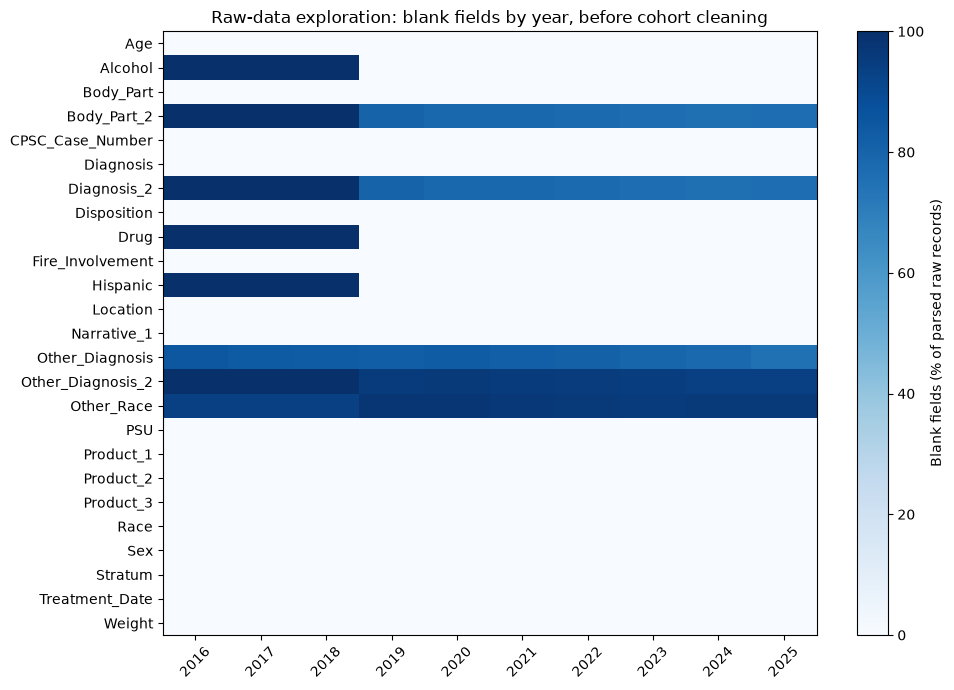

In [4]:
# RAW EDA 3: schema, blank fields and categorical codes.
# A literal code such as Age=0 is not a blank.
display(raw_profiles["fields"].groupby("field", sort=False).agg(
    loaded_dtype=("loaded_dtype", "first"), blank_n=("blank_n", "sum"),
    numeric_parse_failure_n=("numeric_parse_failure_n", lambda x: x.sum(min_count=1))))
display(raw_profiles["codes"].groupby(["field", "raw_code", "label"], dropna=False).n.sum().reset_index())
missing_matrix = raw_profiles["fields"].pivot(index="field", columns="year", values="blank_percent")
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(missing_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(missing_matrix.columns)), missing_matrix.columns, rotation=45)
ax.set_yticks(range(len(missing_matrix.index)), missing_matrix.index)
ax.set_title("Raw-data exploration: blank fields by year, before cohort cleaning")
fig.colorbar(im, ax=ax, label="Blank fields (% of parsed raw records)")
fig.tight_layout()
plt.show()
plt.close(fig)
# Pre-2019 structural absence is not a reason to impute the six later-added fields.

### Recorded ages and survey weights

The left-hand plot displays raw age codes. Codes 201–223 represent months, not people aged over 200. The cleaned data preserve the original code and a decoded age in years. The documented code 201 also covers newborns, so its numerical conversion is a coding convention rather than an exact age for every infant.

The right-hand plot compares the mean, median and 1st–99th percentiles of the survey weights. A weight determines how much a sampled presentation contributes to a national estimate. Large positive weights are not automatically errors or outliers to remove. Zero, negative and non-finite weights are checked separately.

These plots describe the full raw sample. They do not yet describe the sport cohort or measure injury risk. A change in weights is investigated with the survey documentation and sensitivity checks; the plot alone cannot establish its cause.

,year,unknown_age_code_0,other_invalid_age,infant_month_codes,zero_weight,negative_weight,nonfinite_weight,observed_psus
0,2016,49,0,22572,0,0,0,84
1,2017,20,0,22818,0,0,0,89
2,2018,18,0,21264,0,0,0,88
3,2019,37,0,21505,0,0,0,84
4,2020,28,0,20753,0,0,0,82
5,2021,29,0,21365,0,0,0,80
6,2022,33,0,20176,0,0,0,78
7,2023,23,0,19321,0,0,0,78
8,2024,29,0,21952,0,0,0,77
9,2025,45,0,24339,0,0,0,77


,year,mean,min,p01,p25,median,p75,p99,max
0,2016,38.17,4.51,4.51,14.65,16.12,63.74,103.23,103.23
1,2017,38.07,4.76,4.76,15.45,16.99,75.57,87.09,87.09
2,2018,38.60,4.94,4.94,16.59,18.54,72.84,86.22,86.22
3,2019,37.53,4.83,4.83,15.64,18.40,74.44,86.84,86.84
4,2020,35.54,4.85,4.85,16.00,16.84,73.80,78.41,78.41
5,2021,34.48,4.85,4.85,15.44,17.07,68.72,76.08,76.08
6,2022,39.16,5.83,5.83,17.22,19.25,77.98,80.97,80.97
7,2023,37.66,7.61,7.61,15.77,17.52,72.02,89.73,89.73
8,2024,41.66,6.58,6.58,27.59,27.59,53.13,108.07,108.07
9,2025,40.19,7.12,7.12,25.55,28.10,51.82,113.12,113.12


,raw_sample_n
raw_age_code,
0,311
2,120819
3,100909
4,84697
5,76880
6,71195
7,67419
8,66347
9,68253


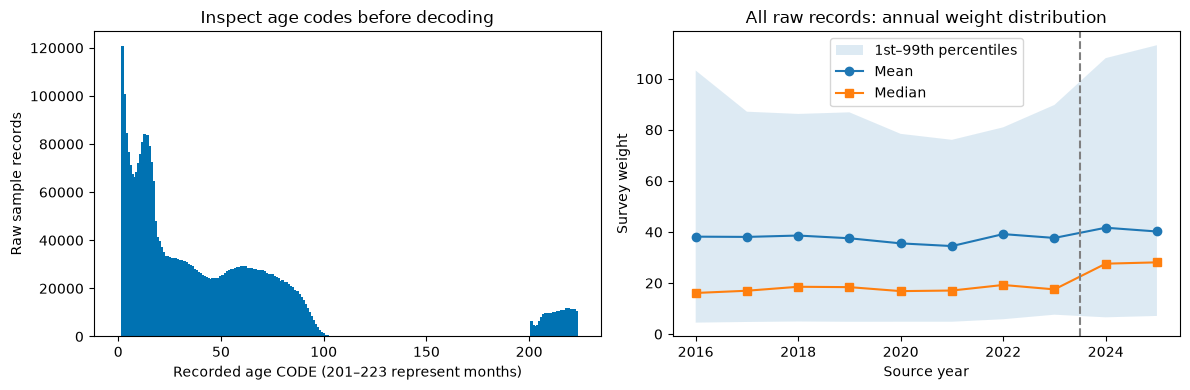

In [5]:
# RAW EDA 4: age coding and annual weight distributions.
display(raw_overview[["year", "unknown_age_code_0", "other_invalid_age", "infant_month_codes",
                      "zero_weight", "negative_weight", "nonfinite_weight", "observed_psus"]])
display(raw_profiles["weights"].round(2))
raw_age_distribution = raw_profiles["age_counts"].copy()
raw_age_distribution["code_number"] = pd.to_numeric(raw_age_distribution.raw_age_code, errors="coerce")
display(raw_age_distribution.groupby("raw_age_code").n.sum().rename("raw_sample_n").to_frame().head(15))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ages_plot = raw_age_distribution.groupby("code_number").n.sum().sort_index()
axes[0].bar(ages_plot.index, ages_plot.values, width=1.5, color="#0072B2")
axes[0].set(xlabel="Recorded age CODE (201–223 represent months)", ylabel="Raw sample records",
            title="Inspect age codes before decoding")
w = raw_profiles["weights"].sort_values("year")
axes[1].fill_between(w.year, w.p01, w.p99, alpha=.15, label="1st–99th percentiles")
axes[1].plot(w.year, w["mean"], marker="o", label="Mean")
axes[1].plot(w.year, w["median"], marker="s", label="Median")
axes[1].axvline(2023.5, color="grey", linestyle="--")
axes[1].set(xlabel="Source year", ylabel="Survey weight", title="All raw records: annual weight distribution")
axes[1].legend()
fig.tight_layout()
plt.show()
plt.close(fig)
# These are raw SAMPLE diagnostics, not sport burden or population incidence.
# Large positive weights are design features to investigate, not automatic outliers to remove.


**What the age and weight checks found.** There are 311 records coded with unknown age across the full parsed source data. Only 78 otherwise eligible Extended records have unknown age; 27 of those also qualify for Core. The smaller figures describe the study selection, not the entire source dataset.

No numeric zero, negative or non-finite survey weights were found among structurally valid rows. This corrects the earlier concern that valid zero-weight records were present. The subsequent exclusion table shows whether each quality issue actually removes eligible records.

### Turning the checks into cleaning decisions

The issue table separates observed problems from the rules used to handle them. The flow table then applies the rules in sequence: identify qualifying products, require usable survey design fields, require a documented known age, and check the treatment year. Each step starts from the records retained at the previous step, so a record cannot be counted as removed twice in that flow.

The Core row is a subset of the final Extended cohort. Records outside Core are not necessarily dirty or invalid; many are valid recreational presentations intentionally included only in the broader comparison. Product classification is a research-scope decision, whereas excluding an unknown age follows from an age-focused question.

In [6]:
# RAW EDA 5: use the evidence to justify cleaning and preview exclusions.
cleaning_plan = pd.DataFrame([
    ("Schema / encoding / malformed rows", int(raw_overview.rejected_fragments.sum()),
     "Validate 25 fields; log rejected fragments; use verified encoding fallback."),
    ("Unknown age code 0", int(raw_overview.unknown_age_code_0.sum()),
     "Retain raw code for audit; exclude unknown ages from this age-focused cohort."),
    ("Other invalid age", int(raw_overview.other_invalid_age.sum()),
     "Reject undocumented codes; decode 201–223 as months, not years."),
    ("Invalid survey design", int(raw_overview.invalid_design_rows.sum()),
     "Require finite positive weights, integral positive PSU and recognised stratum."),
    ("Duplicate identifier rows", int(raw_overview.duplicate_id_rows.sum()),
     "Investigate; preparation stops for duplicate eligible cases. Do not blindly deduplicate."),
    ("Invalid treatment date/year", int(raw_overview.invalid_date_or_year.sum()),
     "Require a parsed date belonging to the source year."),
], columns=["issue", "raw_rows_or_fragments", "cleaning_rule"])
display(cleaning_plan)
flow_order = raw_profiles["flow"].stage.drop_duplicates().tolist()
flow_preview = raw_profiles["flow"].groupby("stage", sort=False)[["remaining_n", "removed_at_step"]].sum().reindex(flow_order)
display(flow_preview)
print("Flow counts are sequential; individual issue totals above can overlap.")
print("Next: apply these rules (PREPARE_DATA=True) or validate the packaged prepared cohort.")
# Scientific cohort choices are declared in the taxonomy, not selected to maximise results.
# Fishing is Core; bleachers cannot establish eligibility. Cycling/playground are Extended.
# Fields introduced in 2019 remain excluded from the common-window analysis.


,issue,raw_rows_or_fragments,cleaning_rule
0,Schema / encoding / malformed rows,16,Validate 25 fields; log rejected fragments; us...
1,Unknown age code 0,311,Retain raw code for audit; exclude unknown age...
2,Other invalid age,0,Reject undocumented codes; decode 201–223 as m...
3,Invalid survey design,0,"Require finite positive weights, integral posi..."
4,Duplicate identifier rows,0,Investigate; preparation stops for duplicate e...
5,Invalid treatment date/year,0,Require a parsed date belonging to the source ...


,remaining_n,removed_at_step
stage,,
All parsed raw records,3565766,0
Qualifying P1 or P2,978925,2586841
Then valid survey design,978925,0
Then known valid age,978847,78
Then valid treatment year,978847,0
Core subset of final Extended,659637,319210


Flow counts are sequential; individual issue totals above can overlap.
Next: apply these rules (PREPARE_DATA=True) or validate the packaged prepared cohort.


### Defining Core and Extended

NEISS defines 1,124 product codes and there is no sport flag. The analytical population is therefore an explicit taxonomy, built by reviewing every candidate code against its official CPSC label and recorded in product_classification.csv with a rationale and review status for each code. Of 173 candidates, 84 are Core, 123 Extended, 50 reviewed and excluded, and none left unreviewed.

Core covers codes classified as sport and exercise; this does not establish active participation. Extended adds broader recreation: playground equipment, cycling, water recreation, scooters, skateboards and trampolines. Core is the analytical population and Extended the sensitivity comparison. Two boundary decisions are worth stating. Cycling and playground equipment are Extended, not Core, because their product codes do not establish sport participation. Cycling can include transport, and playground equipment can include general childhood play. Their inclusion can change the age distribution, so they belong in the broader comparison rather than being silently treated as sport. Fishing is included as sport. Bleachers cannot establish eligibility, although a separate qualifying sport code can.

Eligibility is Product_1 or Product_2; Product_3 is excluded because it was not collected before 2019 and would give later years more chances to qualify. Activity attribution takes the first product qualifying for the relevant cohort, otherwise Product_2. An excluded first product cannot override a qualifying second product. One row is one presentation: unique case numbers equal cohort rows in every year, so no deduplication is required. One presentation per row and one variable per column follows tidy-data principles (Wickham, 2014).

### Grouping body regions and diagnoses

The 30 body parts and 31 diagnoses are collapsed into interpretable groups, to make comparisons easier to read. The grouping reduces detail, so the original codes are retained and the mapping tables remain available for inspection. Both mappings are generated by joining on the official CPSC label text, not typed by hand, and every row carries a verification status.

An earlier hand-entered version had diagnosis codes 62 (INTERNAL INJURY) and 64 (STRAIN, SPRAIN) transposed, along with five other diagnosis and four body-part codes. The historical diagnosis output was therefore wrong. The notebook now asserts the mapping content at load time, so a repeat would fail the run rather than produce a plausible figure.

### Preparing the study datasets

The code loads the prepared data, or rebuilds them from the source files using the agreed rules. It separates Core and Extended records and checks their yearly totals against the earlier exclusion counts.


The variable table distinguishes measurement level from storage type: numerical codes for sex, diagnosis and products are categories, not measured quantities. Ranges describe the cleaned cohorts. Blank percentages use all records in each cohort; separately reported unknown codes are not counted as blanks. A blank in the coded-unknown percentage column means that this particular check does not apply. Age exclusions are quantified in the preceding raw-data exploration. No values are imputed in this descriptive analysis. Assigning average ages or the most frequent clinical category could shift the patterns being studied. More sophisticated imputation would require a justified model and checks of its assumptions, which this project does not provide. Unknown age is excluded because age is essential to every question. Other exclusions are specific to the analysis that needs the field. The small age exclusion does not prove that missingness is unbiased.

The short record preview shows actual cleaned rows with their raw and decoded ages, category codes, assigned activity and weights. It is a layout example, not a random sample or evidence of the overall distribution. Case identifiers, treatment dates and narrative text are omitted from this display. The following variable summary describes the whole cohort.

In [7]:
PREPARE_DATA = False  # Change to True for your first data preparation run.
if PREPARE_DATA:
    preparation_log = neiss.prepare_data(RAW_SOURCE_DIR)
    display(preparation_log)

data, roster = neiss.load_data()
core_codes, extended_codes, activity_map, classification = neiss.taxonomy()
core = data.loc[data.In_Core].copy()
core["Activity"] = core.Activity_Core
extended = data.copy()
extended["Activity"] = extended.Activity_Extended

quality_log = pd.read_csv(PROJECT_ROOT / "data/data_quality_log.csv")
manifest = pd.read_csv(PROJECT_ROOT / "data/data_manifest.csv")
display(quality_log)
display(classification.loc[classification.product_code.isin([3223, 1294]),
    ["product_code", "official_label", "include_core", "include_extended", "rationale"]])
display(pd.DataFrame({
    "cohort": ["Core", "Extended"],
    "sample_n": [len(core), len(extended)],
    "years": [core.Source_Year.nunique(), extended.Source_Year.nunique()],
    "unknown_sex_n": [core.Sex.eq(0).sum(), extended.Sex.eq(0).sum()],
}))
print("Raw parsed rows:", int(quality_log.parsed_rows.sum()))
print("Parser-rejected records:", int(quality_log.parser_rejected_records.sum()))
print("Eligible records excluded by quality rules:", int(quality_log.eligible_excluded_unique.sum()))
assert set(data.Source_Year) == set(YEARS)
assert not data.duplicated(["Source_Year", "CPSC_Case_Number"]).any()
assert core.In_Core.all()

# Validate actual preparation against the BEFORE-cleaning exploration preview.
for stage, actual in [("Then valid treatment year", extended), ("Core subset of final Extended", core)]:
    expected = raw_profiles["flow"].loc[lambda x: x.stage.eq(stage)].set_index("year").remaining_n.sort_index()
    observed = actual.groupby("Source_Year").size().reindex(expected.index, fill_value=0)
    assert np.array_equal(expected.to_numpy(), observed.to_numpy()), f"EDA/cleaning mismatch: {stage}"
qa_compare = raw_overview.set_index("year").join(quality_log.set_index("year"), rsuffix="_clean")
assert qa_compare.rows.eq(qa_compare.parsed_rows).all()
assert qa_compare.rejected_fragments.eq(qa_compare.parser_rejected_records).all()
print("Raw exploration and cleaned annual cohort counts agree for both cohorts.")

# Show the structure of actual cleaned rows without identifiers or narratives.
display(core[["Source_Year", "Age_Raw", "Age_Years", "Sex", "Body_Part",
              "Diagnosis", "Disposition", "Activity", "Weight"]].head(5))

# Summarise analytical variables after cleaning; these are sample descriptions.
variable_definitions = [
    ("Age_Years", "Ratio", "Years", "Unknown age excluded before cohort construction"),
    ("Sex", "Nominal", "CPSC code", "0 means unknown; retained except in sex-specific curves"),
    ("Body_Part", "Nominal", "CPSC code", "87 means not stated/unknown; retained as coded"),
    ("Diagnosis", "Nominal", "CPSC code", "Other diagnoses remain in composition denominators"),
    ("Disposition", "Nominal", "CPSC code", "Only codes 1, 2, 4, 5, 8 enter care-outcome analysis"),
    ("Product_1", "Nominal", "CPSC code", "Eligibility may instead come from Product_2"),
    ("Product_2", "Nominal", "CPSC code", "0 indicates no second product, not a missing observation"),
    ("Source_Year", "Interval", "Calendar year", "2016 to 2025; checked against treatment date"),
    ("Weight", "Ratio", "Estimated presentations per sampled record", "Positive finite survey weights required"),
    ("PSU", "Nominal", "Hospital identifier", "Used with Stratum and Source_Year for survey estimation"),
    ("Stratum", "Nominal", "Hospital stratum", "Survey design category, not a numerical scale"),
]
variable_rows = []
for cohort_name, frame in [("Core", core), ("Extended", extended)]:
    for field, level, units, treatment in variable_definitions:
        values = frame[field]
        observed = (f"{values.min():.4g} to {values.max():.4g}" if level != "Nominal"
                    else f"{values.nunique()} observed categories")
        unknown = (100 * values.eq(0).mean() if field == "Sex" else
                   100 * values.eq(87).mean() if field == "Body_Part" else np.nan)
        variable_rows.append({"cohort": cohort_name, "variable": field,
            "measurement_level": level, "units": units, "observed_range_or_categories": observed,
            "blank_percent": 100 * values.isna().mean(), "coded_unknown_percent": unknown,
            "handling": treatment})
variable_summary = pd.DataFrame(variable_rows)
display(variable_summary.round(4))
variable_summary.to_csv(PROJECT_ROOT / "tables/variable_summary.csv", index=False)


,year,parsed_rows,parser_rejected_records,invalid_design_unique,zero_weight,invalid_weight,invalid_psu,invalid_stratum,same_weight_psu_stratum_masks,invalid_age,invalid_date_or_year,unknown_age,eligible_unknown_age,eligible_invalid_age,eligible_before_quality,eligible_excluded_unique,sex_reclassified_unknown,extended_rows,core_rows,two_extended_products
0,2016,375196,0,0,0,0,0,0,True,49,0,49,10,10,107706,10,0,107696,76072,2025
1,2017,386905,2,0,0,0,0,0,True,20,0,20,6,6,110097,6,0,110091,77760,2425
2,2018,361666,2,0,0,0,0,0,True,18,0,18,4,4,98732,4,0,98728,69959,2245
3,2019,358714,2,0,0,0,0,0,True,37,0,37,8,8,98171,8,0,98163,67988,2367
4,2020,309370,0,0,0,0,0,0,True,28,0,28,11,11,71311,11,0,71300,41715,1729
5,2021,340440,4,0,0,0,0,0,True,29,0,29,4,4,89832,4,0,89828,57171,1964
6,2022,323343,0,0,0,0,0,0,True,33,0,33,6,6,90925,6,0,90919,60503,1988
7,2023,338259,6,0,0,0,0,0,True,23,0,23,10,10,95241,10,0,95231,64571,1884
8,2024,361672,0,0,0,0,0,0,True,29,0,29,7,7,104493,7,0,104486,69847,2270
9,2025,410201,0,0,0,0,0,0,True,45,0,45,12,12,112417,12,0,112405,74051,2624


,product_code,official_label,include_core,include_extended,rationale
21,3223,"FISHING (ACTIVITY, APPAREL OR EQUIPMENT)",True,True,Core: sporting or skating activity (informal p...
47,1294,BLEACHERS,False,False,Excluded: seating infrastructure; product asso...


,cohort,sample_n,years,unknown_sex_n
0,Core,659637,10,101
1,Extended,978847,10,183


Raw parsed rows: 3565766
Parser-rejected records: 16
Eligible records excluded by quality rules: 78


Raw exploration and cleaned annual cohort counts agree for both cohorts.


,Source_Year,Age_Raw,Age_Years,Sex,Body_Part,Diagnosis,Disposition,Activity,Weight
0,2016,30,30.0,1,92,64,1,Volleyball,103.2251
1,2016,19,19.0,2,75,59,1,Water sports,103.2251
2,2016,28,28.0,1,30,64,1,Exercise/fitness,103.2251
4,2016,12,12.0,1,92,64,1,Football,103.2251
5,2016,18,18.0,1,94,71,1,Swimming/diving,87.7206


,cohort,variable,measurement_level,units,observed_range_or_categories,blank_percent,coded_unknown_percent,handling
0,Core,Age_Years,Ratio,Years,0.08333 to 108,0.0,NaN,Unknown age excluded before cohort construction
1,Core,Sex,Nominal,CPSC code,3 observed categories,0.0,0.0153,0 means unknown; retained except in sex-specif...
2,Core,Body_Part,Nominal,CPSC code,26 observed categories,0.0,0.5195,87 means not stated/unknown; retained as coded
3,Core,Diagnosis,Nominal,CPSC code,30 observed categories,0.0,NaN,Other diagnoses remain in composition denomina...
4,Core,Disposition,Nominal,CPSC code,7 observed categories,0.0,NaN,"Only codes 1, 2, 4, 5, 8 enter care-outcome an..."
5,Core,Product_1,Nominal,CPSC code,476 observed categories,0.0,NaN,Eligibility may instead come from Product_2
6,Core,Product_2,Nominal,CPSC code,495 observed categories,0.0,NaN,"0 indicates no second product, not a missing o..."
7,Core,Source_Year,Interval,Calendar year,2016 to 2025,0.0,NaN,2016 to 2025; checked against treatment date
8,Core,Weight,Ratio,Estimated presentations per sampled record,4.506 to 113.1,0.0,NaN,Positive finite survey weights required
9,Core,PSU,Nominal,Hospital identifier,103 observed categories,0.0,NaN,Used with Stratum and Source_Year for survey e...


### What the prepared cohorts contain

The checks retain 659,637 Core presentations and 978,847 Extended presentations. Core is included within Extended. These are counts across ten years, not annual national estimates. The recorded sample is concentrated in younger ages; survey weighting is applied later when estimating national totals and composition.

Table 1. Unweighted sample demographics; percentages use all cohort records.

| Measure | Core | Extended |
| --- | --- | --- |
| Records | 659,637 | 978,847 |
| Median age (years) | 16 | 15 |
| Under 18 (%) | 61.39 | 62.37 |
| Male (%) | 68.10 | 65.18 |
| Unknown sex (%) | 0.015 | 0.019 |

Evidence: the live cohort checks above and `tables/sample_demographics.csv`, recalculated in the annual-summary cell below.

### Estimating totals and deciding what can be displayed

Three different quantities are used:

| Quantity | Calculation | Interpretation |
| --- | --- | --- |
| Sample count | Number of included records | Presentations actually recorded by sampled hospitals |
| Average annual national estimate | Sum of survey weights across the study window, divided by its number of years | Estimated presentations per year in the population covered by NEISS |
| Weighted percentage | Weight sum for a category divided by the weight sum for its stated comparison group, multiplied by 100 | Composition of presentations in that group |

Figures 3 and 4 divide by all Core presentations within each age band. Figure 5 instead divides by all presentations within each selected activity. Figure 7 divides only by records with eligible care outcomes in each age band. Those percentages answer different questions and should not be compared as though their denominators were identical.

The code retains full denominators before masking unreliable results. It does not remove suppressed categories and then rescale the visible values to 100%. A blank or missing line segment means that an estimate was withheld, not that no injuries occurred.

The display rule requires at least 20 sample records, an estimated total of at least 1,200 and a finite coefficient of variation (CV) no greater than 0.33. CV expresses estimated uncertainty relative to the estimate’s size. Percentages must also pass their own CV check. For pooled results, the total threshold is applied to the average annual estimate; Figure 1 is assessed year by year. These are the project’s adaptations of CPSC guidance, not an official certification of multi-year estimates.

Uncertainty is estimated between hospitals within survey strata, because the hospital is the sampling unit. The calculation includes hospitals that contributed no records to a particular category. Dropping those hospitals would change the uncertainty calculation.

The same hospitals may appear in several years. The code therefore uses an upper bound on the uncertainty of the pooled estimate instead of assuming independent annual samples. For annual standard errors s_y, the standard deviation of their summed estimates is bounded by sum(s_y). Dividing by the number of years gives the bound for an average annual total. Percentage calculations use hospital residuals N − pD to retain the relationship between numerator and denominator. Finite-population and ratio-adjustment corrections are omitted, so the bound is conservative relative to this approximation, not a guarantee about the exact survey uncertainty.

### Checking the analysis rules

Small examples check that unreliable estimates are withheld and that either qualifying product field can establish eligibility. These checks help catch coding mistakes before figures are produced.


In [8]:
# Behaviour checks run only when you execute this cell.
assert neiss.reliability(19, 5000, 0.10)[0] is False
assert neiss.reliability(25, 900, 0.10)[0] is False
assert neiss.reliability(25, 5000, 0.45)[0] is False
assert neiss.reliability(25, 5000, None)[0] is False
assert neiss.reliability(25, 5000, np.nan)[0] is False
assert neiss.reliability(25, 5000, 0.10)[0] is True

# Excluded P1 must not override a qualifying P2.
toy = pd.DataFrame({"Product_1": [1294, 3223, np.nan],
                    "Product_2": [1205, 1205, 3223]})
assert neiss.attribute(toy, core_codes, activity_map).tolist() == [
    activity_map[1205], activity_map[3223], activity_map[3223]
]

# A finite missing/zero denominator must never be declared a reportable proportion.
print("Basic logic assertions passed; these are not empirical validation of the survey method.")


Basic logic assertions passed; these are not empirical validation of the survey method.


### Creating consistent figures and tables

Shared functions apply the same formatting, reliability rules and saving process across the analysis. This keeps the figures consistent and ensures tables and charts treat unreliable estimates in the same way.


In [9]:
ORANGE, BLUE, GREEN, PURPLE = "#D98200", "#0072B2", "#009E73", "#9B5A8C"
COLOURS = [ORANGE, BLUE, GREEN, PURPLE, "#D55E00", "#666666"]
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.facecolor": "white", "savefig.dpi": 300,
})
WRITTEN_FIGURES = []
def save_figure(fig, name, note, bottom=0.20):
    fig.text(0.01, 0.01, note, fontsize=8, ha="left", va="bottom", wrap=True)
    fig.subplots_adjust(bottom=bottom)
    fig.savefig(FIGURES / name, dpi=300, bbox_inches="tight", facecolor="white")
    WRITTEN_FIGURES.append(name)
    plt.show()
    plt.close(fig)

def publish_table(table, name):
    clean = neiss.report_table(table) if "reportable" in table else table.copy()
    clean.to_csv(TABLES / f"{name}.csv", index=False)
    return clean

def summarise(frame, groups, name, denominator=None, catalog=None, years=YEARS):
    pooled, annual = neiss.domain_summary(
        frame, roster, groups, denominator=denominator, catalog=catalog, years=years
    )
    publish_table(pooled, name)
    # Annual point estimates are withheld where their annual screen fails.
    annual_public = annual.copy()
    annual_public.loc[~annual_public.annual_pass, "estimate"] = np.nan
    annual_public["estimate"] = annual_public.estimate.round(-2)
    annual_public.to_csv(TABLES / f"{name}_annual_diagnostics.csv", index=False)
    return pooled, annual

def safe_values(table, column):
    return table[column].where(table.reportable)

SCREEN_NOTE = "NEISS 2016–2025. Weighted. Failed conservative reliability screens are not drawn."


## 4  Analysis and results

### Annual presentation totals

The annual plot puts the pooled analyses in context. It shows how the estimated number of presentations varies across the study window, including the 2020 decline and the hospital-sample change from 2024. A change in the line is an observation to investigate, not an explanation of why it occurred.

**Method.** The code calculates annual presentation estimates and basic sample summaries for both cohorts. The yearly plot shows changes in volume, including the change in the hospital sample from 2024.


,cohort,n,estimate_rounded,cv_bound,reportable,reason
0,Core,659637,2334700.0,0.104599,True,passes conservative screen
1,Extended,978847,3400700.0,0.101070,True,passes conservative screen


,cohort,sample_n,sample_median_age,sample_percent_under18,sample_percent_male,sample_percent_unknown_sex
0,Core,659637,16.0,61.39,68.10,0.02
1,Extended,978847,15.0,62.37,65.18,0.02


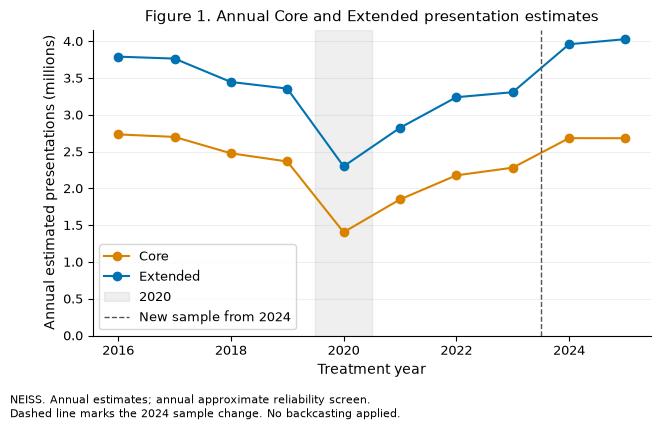

In [10]:
overview_rows, annual_totals = [], []
for label, frame in [("Core", core), ("Extended", extended)]:
    t, a = summarise(frame, ["All"], f"overview_{label.lower()}")
    t["cohort"], a["cohort"] = label, label
    overview_rows.append(t)
    annual_totals.append(a)
overview = pd.concat(overview_rows, ignore_index=True)
display(neiss.report_table(overview)[["cohort", "n", "estimate_rounded", "cv_bound", "reportable", "reason"]])

sample_overview = pd.DataFrame([
    {"cohort": label, "sample_n": len(frame),
     "sample_median_age": frame.Age_Years.median(),
     "sample_percent_under18": 100 * frame.Age_Years.lt(18).mean(),
     "sample_percent_male": 100 * frame.Sex.eq(1).mean(),
     "sample_percent_unknown_sex": 100 * frame.Sex.eq(0).mean()}
    for label, frame in [("Core", core), ("Extended", extended)]
])
display(sample_overview.round(2))
publish_table(sample_overview, "sample_demographics")

annual_volume = pd.concat(annual_totals, ignore_index=True)
fig, ax = plt.subplots(figsize=(7.2, 4.5))
for label, colour in [("Core", ORANGE), ("Extended", BLUE)]:
    t = annual_volume.loc[annual_volume.cohort.eq(label)].sort_values("Source_Year")
    y = t.estimate.where(t.annual_pass) / 1e6
    ax.plot(t.Source_Year, y, marker="o", color=colour, label=label)
ax.axvspan(2019.5, 2020.5, color="grey", alpha=0.12, label="2020")
ax.axvline(2023.5, color="#555555", ls="--", lw=1, label="New sample from 2024")
ax.set(xlabel="Treatment year", ylabel="Annual estimated presentations (millions)",
       title="Figure 1. Annual Core and Extended presentation estimates")
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "figure_01_annual_volume.png",
    "NEISS. Annual estimates; annual approximate reliability screen.\n"
    "Dashed line marks the 2024 sample change. No backcasting applied.")

**Observed totals.** Core has an average annual national estimate of 2,334,700 presentations; Extended has 3,400,700. These are annual estimates, whereas the demographics table counts sampled records across all ten years. The dashed line marks the sample change; no backcasting has been applied here. The 2020 decline is retained and later tested by excluding that year.

Evidence: `tables/overview_core.csv`, `tables/overview_extended.csv` and their annual diagnostics.

### 4.1  RQ1: How presentations vary by age and recorded sex

The code estimates average annual presentation totals at each completed year of age. Keeping single-year ages makes narrow peaks visible; wider age bands would combine neighbouring ages. The two panels compare Core with Extended, then compare recorded male and female Core presentations.

Unknown sex is retained in the overall cohort but omitted from the sex-specific curves. The curves therefore do not sum exactly to the whole-cohort curve. Ages 90 and over are grouped in the calculations, and a value is drawn only if it passes the display rule.

**Method.** The code adds survey weights within each age to estimate average annual presentations, then plots Core, Extended and sex-specific curves. Single-year ages show peaks that broader age groups could hide.


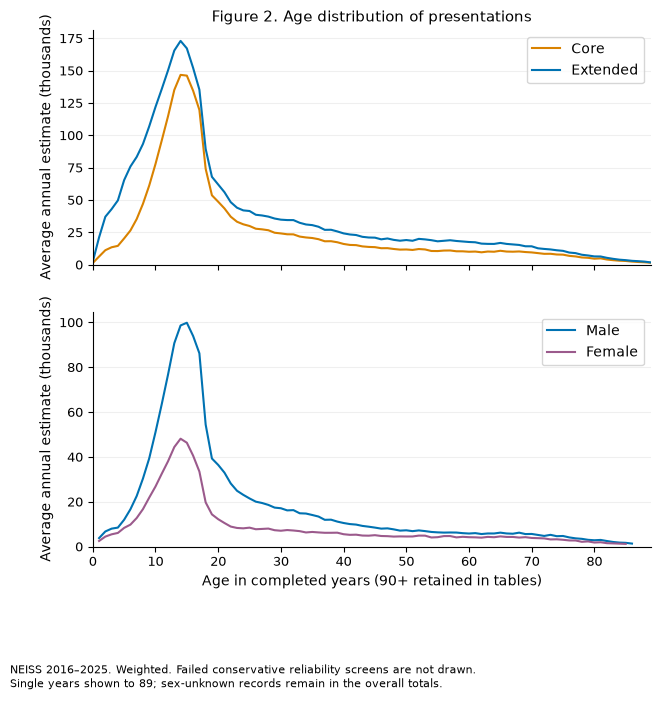

,series,Age_Display,n,estimate_rounded,reportable
90,Core,90,1065,5100.0,True
181,Extended,90,1288,6200.0,True
272,Male,90,521,2600.0,True
363,Female,90,544,2500.0,True


In [11]:
for frame in [core, extended]:
    frame["Age_Display"] = frame.Age_Integer.clip(upper=90)
age_catalog = pd.Index(range(91), name="Age_Display")
age_tables = {}
for label, frame in [("Core", core), ("Extended", extended),
                     ("Male", core.loc[core.Sex.eq(1)]),
                     ("Female", core.loc[core.Sex.eq(2)])]:
    age_tables[label], _ = summarise(frame, ["Age_Display"],
        f"rq1_age_{label.lower()}", denominator=[], catalog=age_catalog)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 7.6), sharex=True)
for label, colour in [("Core", ORANGE), ("Extended", BLUE)]:
    t = age_tables[label].loc[lambda x: x.Age_Display.lt(90)]
    axes[0].plot(t.Age_Display, safe_values(t, "estimate") / 1000, label=label, color=colour)
for label, colour in [("Male", BLUE), ("Female", PURPLE)]:
    t = age_tables[label].loc[lambda x: x.Age_Display.lt(90)]
    axes[1].plot(t.Age_Display, safe_values(t, "estimate") / 1000, label=label, color=colour)
for ax in axes:
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Average annual estimate (thousands)")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
axes[0].set_title("Figure 2. Age distribution of presentations")
axes[1].set(xlabel="Age in completed years (90+ retained in tables)", xlim=(0, 89))
save_figure(fig, "figure_02_lifespan.png", SCREEN_NOTE + "\nSingle years shown to 89; sex-unknown records remain in the overall totals.")
display(pd.concat([neiss.report_table(t).assign(series=k)
                   for k, t in age_tables.items()], ignore_index=True)
        .loc[lambda x: x.Age_Display.eq(90),
             ["series", "Age_Display", "n", "estimate_rounded", "reportable"]])


**What the results show.** The Core estimate at age 14 is 146,800 average annual presentations, compared with 16,000 at age 40. The first is about 9.2 times the second, using the rounded published estimates. The male curve peaks at 15 and the female curve at 14. These are totals among presentations, not the probability that a male or female participant is injured.

Differences between ages could reflect participation, the type of activity, injury occurrence or the choice of care setting. These data do not separate those explanations. Evidence: `tables/rq1_age_core.csv`, `tables/rq1_age_male.csv` and `tables/rq1_age_female.csv`.

### 4.2  RQ2: How injured body regions vary by age

For each age band, the code divides the weight assigned to each body region by the weight of all Core presentations in that age band. A value of 52% therefore describes the composition of that age group’s presentations; it does not mean 52% of children were injured.

The heatmap compares many regions across many ages in one view. Regions are ordered broadly from head to toe. A light-to-dark colour scale represents increasing percentages without suggesting an artificial midpoint. A bar chart for every age band would require considerably more space. Suppressed categories stay in the denominator.

**Method.** The code calculates the percentage of presentations affecting each body region within each age group. The heatmap compares injury patterns across ages even when the groups contain very different numbers of presentations.


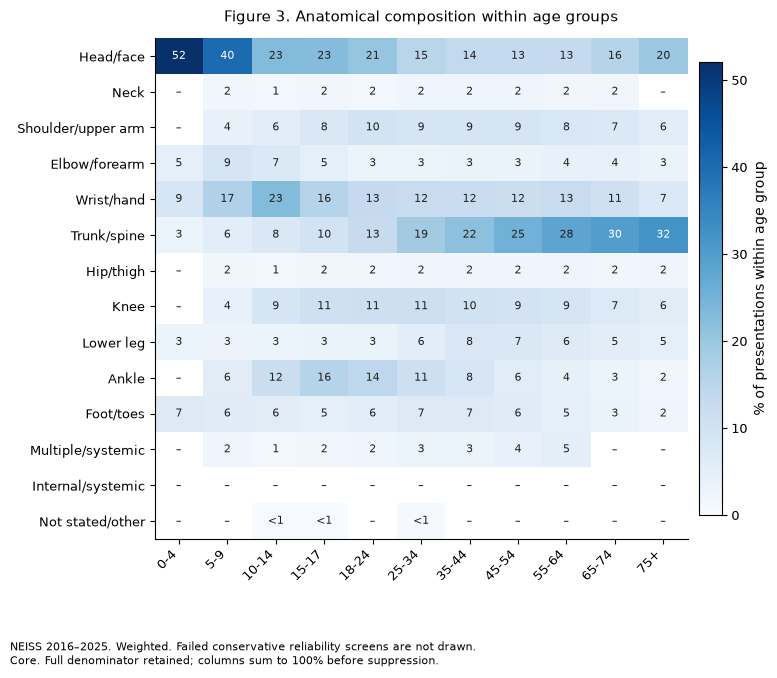

,sum,size
Age_Band,,
0-4,6,14
10-14,13,14
15-17,13,14
18-24,12,14
25-34,13,14
35-44,12,14
45-54,12,14
5-9,12,14
55-64,12,14


In [12]:
bp_catalog = pd.MultiIndex.from_product(
    [neiss.REGION_ORDER, neiss.AGE_LABELS], names=["Body_Region", "Age_Band"]
)
anatomy, _ = summarise(core, ["Body_Region", "Age_Band"], "rq2_anatomy",
                       denominator=["Age_Band"], catalog=bp_catalog)
heat = anatomy.assign(value=safe_values(anatomy, "percent")).pivot(
    index="Body_Region", columns="Age_Band", values="value"
).reindex(index=neiss.REGION_ORDER, columns=neiss.AGE_LABELS)
finite = heat.to_numpy()[np.isfinite(heat.to_numpy())]
if not len(finite):
    raise ValueError("No reportable anatomy cells; investigate before plotting.")
vmax = max(float(finite.max()), 1.0)
fig, ax = plt.subplots(figsize=(7.8, 6.8))
im = ax.imshow(heat, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat.index)), heat.index)
for i in range(len(heat)):
    for j in range(len(heat.columns)):
        v = heat.iloc[i, j]
        ax.text(j, i, "–" if pd.isna(v) else ("<1" if 0 < v < 1 else f"{v:.0f}"), ha="center", va="center",
                fontsize=8, color="white" if pd.notna(v) and v > 0.55*vmax else "#222222")
ax.set_title("Figure 3. Anatomical composition within age groups", pad=12)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="% of presentations within age group")
fig.tight_layout(rect=(0, 0.08, 1, 1))
save_figure(fig, "figure_03_anatomy.png", SCREEN_NOTE + "\nCore. Full denominator retained; columns sum to 100% before suppression.")
display(anatomy.groupby("Age_Band", observed=True).reportable.agg(["sum", "size"]))


**What the results show.** Head/face represents 52.1% of Core presentations at ages 0–4 and 13.3% at ages 45–54. Trunk/spine represents 5.6% at ages 5–9 and 32.2% at ages 75+. These four estimates pass the display rule. The oldest Head/face value is 19.9%, so the pattern is not a continuous decline at every successive age.

These comparisons describe different age groups in pooled records, not the same people followed as they grow older. They do not show that age itself caused the differences or establish an injury mechanism. Evidence: `tables/rq2_anatomy.csv`; the saved table records each value’s sample count, percentage and screening result.

### 4.3  RQ3: How diagnosis groups vary by age

The percentages use the same age-specific denominators as RQ2, but group records by diagnosis. Five diagnosis families are shown separately; every other diagnosis remains in the combined remainder. Lines make changes across ordered age groups easier to follow than a second heatmap (Heer, Bostock and Ogievetsky, 2010).

Markers distinguish series as well as colours. Age bands have unequal widths and are placed at equal visual intervals, so line slopes are not annual rates of change. This is a comparison between age groups, not a time series of patients.

**Method.** The code calculates diagnosis percentages within each age group and plots them as lines. This shows which diagnoses become more or less common in the mix of presentations as age changes.


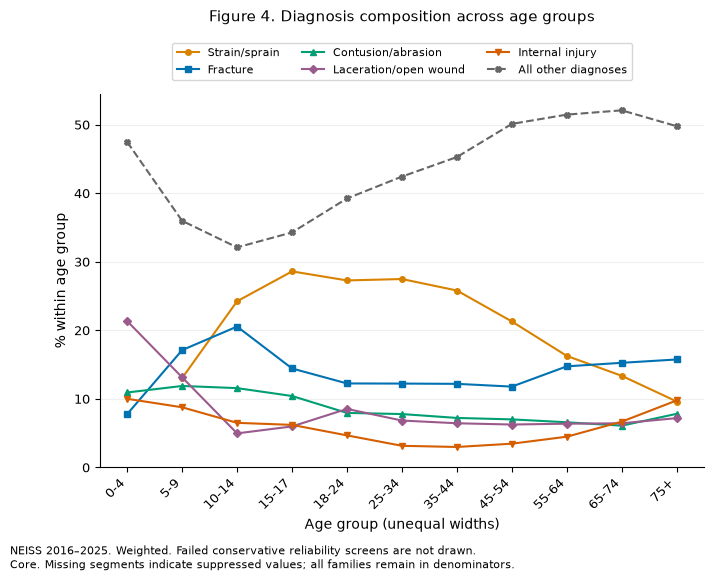

In [13]:
diagnosis_order = neiss.DIAGNOSIS_FOCUS + ["All other diagnoses"]
dg_catalog = pd.MultiIndex.from_product(
    [diagnosis_order, neiss.AGE_LABELS], names=["Diagnosis_Plot", "Age_Band"])
diagnosis, _ = summarise(core, ["Diagnosis_Plot", "Age_Band"], "rq3_diagnosis",
                         denominator=["Age_Band"], catalog=dg_catalog)
fig, ax = plt.subplots(figsize=(7.8, 5.5))
xs = np.arange(len(neiss.AGE_LABELS))
for name, colour, marker in zip(diagnosis_order, COLOURS, ["o", "s", "^", "D", "v", "X"]):
    t = diagnosis.loc[diagnosis.Diagnosis_Plot.eq(name)].set_index("Age_Band").reindex(neiss.AGE_LABELS)
    ax.plot(xs, safe_values(t, "percent"), label=name, marker=marker, ms=4,
            color=colour, ls="--" if name == "All other diagnoses" else "-")
ax.set_xticks(xs, neiss.AGE_LABELS, rotation=45, ha="right")
ax.set(xlabel="Age group (unequal widths)", ylabel="% within age group",
       title="Figure 4. Diagnosis composition across age groups")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2)
ax.legend(ncol=3, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.02))
ax.set_title("Figure 4. Diagnosis composition across age groups", pad=52)
save_figure(fig, "figure_04_diagnosis.png", SCREEN_NOTE + "\nCore. Missing segments indicate suppressed values; all families remain in denominators.")


**What the results show.** Strain/sprain accounts for 28.6% at ages 15–17, 25.8% at 35–44 and 9.6% at 75+. Fracture accounts for 12.2% at 35–44 and 15.8% at 75+. These values describe changes in the mix of presentations, not changes in individual injury risk.

The combined “All other diagnoses” category reaches 52.1% at ages 65–74. It contains multiple diagnoses, so it cannot be interpreted as one clinical condition. Of the 66 displayed category-by-age combinations, 65 pass the screen. Evidence: `tables/rq3_diagnosis.csv`.

### 4.4  RQ4: Comparing age distributions within activities

Each panel asks: among presentations assigned to this activity, what percentage falls in each age band? This reverses the denominator used for anatomy and diagnosis. It allows the shape of a smaller activity’s age distribution to be compared with that of a larger activity without equating their total presentation numbers.

The code selects the 15 largest Core activity groups with at least 3,000 sampled records. The threshold limits the display; it does not establish that all age bands within an activity are reliable. Every plotted activity-age value is screened separately.

Small multiples use matching axes and a common reference curve (Wilke, 2019). The grey curve shows the whole Core age distribution; the coloured curve shows the selected activity. Alphabetical order helps locate an activity, but does not rank activities by age or burden.

**Method.** The code selects the 15 largest activities with at least 3,000 records and calculates age percentages within each activity. Separate panels with shared scales allow activities of different sizes to be compared fairly.


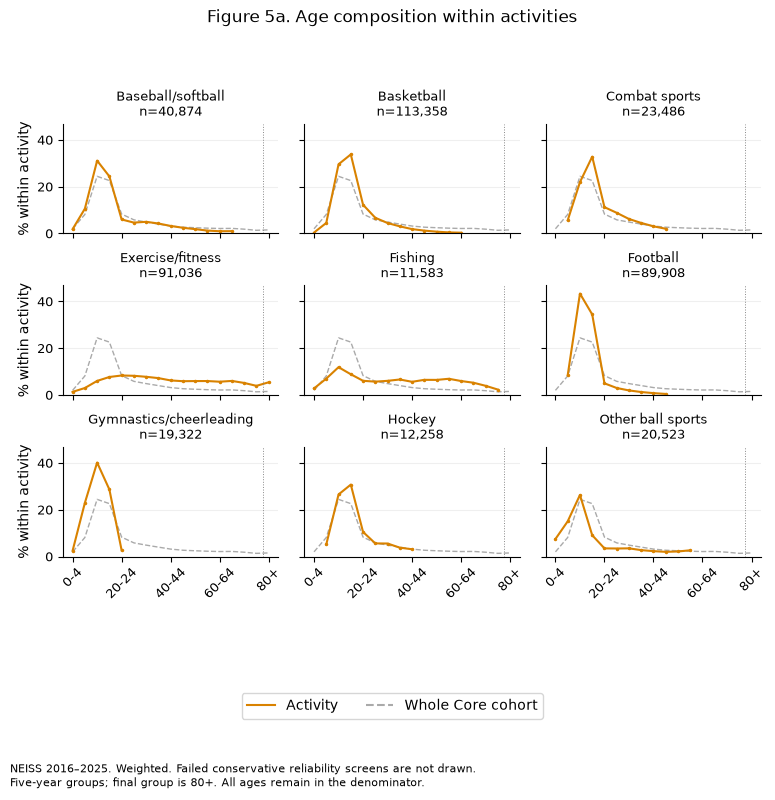

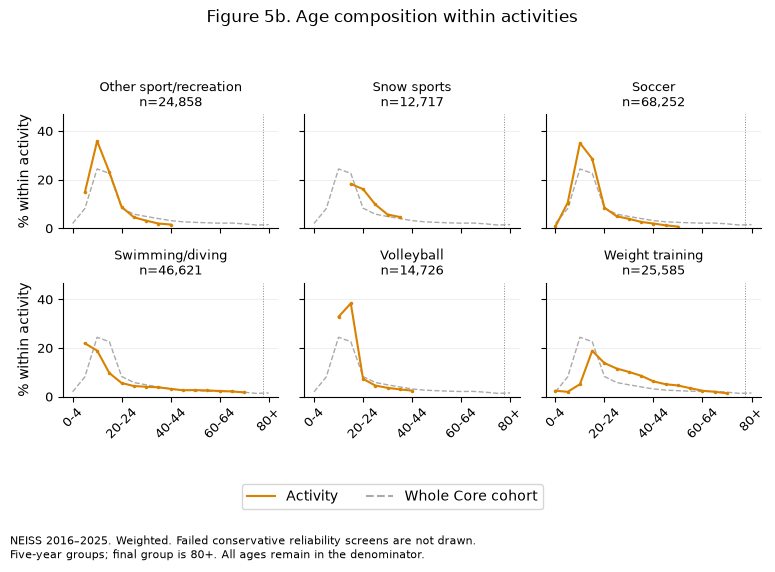

In [14]:
MIN_ACTIVITY_N = 3000
MAX_ACTIVITIES = 15
activity_n = core.groupby("Activity", observed=True).size().sort_values(ascending=False)
ACTIVITIES = activity_n.loc[activity_n.ge(MIN_ACTIVITY_N)].head(MAX_ACTIVITIES).index.tolist()
if not ACTIVITIES:
    raise ValueError("No activities meet the declared selection rule.")
selection = activity_n.rename("sample_n").reset_index()
selection["selected"] = selection.Activity.isin(ACTIVITIES)
publish_table(selection, "rq4_activity_selection")

profile_catalog = pd.MultiIndex.from_product(
    [ACTIVITIES, neiss.PROFILE_LABELS], names=["Activity", "Profile_Age"])
profiles, _ = summarise(core, ["Activity", "Profile_Age"], "rq4_profiles",
                        denominator=["Activity"], catalog=profile_catalog)
reference, _ = summarise(core, ["Profile_Age"], "rq4_overall_reference",
                         denominator=[], catalog=pd.Index(neiss.PROFILE_LABELS, name="Profile_Age"))
reference = reference.set_index("Profile_Age").reindex(neiss.PROFILE_LABELS)

# Limit each export to nine panels so text remains usable in a document.
display_order = sorted(ACTIVITIES)
profile_max = safe_values(profiles, "percent").max()
reference_max = safe_values(reference, "percent").max()
ymax = np.nanmax([profile_max, reference_max])
if not np.isfinite(ymax):
    raise ValueError("No reliable activity-profile values; review age bands.")
for page, start in enumerate(range(0, len(display_order), 9), start=1):
    names = display_order[start:start+9]
    rows = int(np.ceil(len(names) / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(7.8, 2.35*rows + 1.0), sharex=True, sharey=True,
                             squeeze=False)
    for ax, name in zip(axes.flat, names):
        t = profiles.loc[profiles.Activity.eq(name)].set_index("Profile_Age").reindex(neiss.PROFILE_LABELS)
        ax.plot(range(len(t)), safe_values(reference, "percent"), color="#AAAAAA", lw=1, ls="--")
        ax.plot(range(len(t)), safe_values(t, "percent"), color=ORANGE, lw=1.5, marker=".", ms=3)
        ax.axvline(15.5, color="#888888", ls=":", lw=0.7)
        ax.set_title(f"{name}\nn={int(activity_n[name]):,}", fontsize=9)
        ax.set_ylim(0, ymax*1.08)
        ax.grid(axis="y", alpha=0.2)
        ax.set_xticks([0, 4, 8, 12, 16], ["0-4", "20-24", "40-44", "60-64", "80+"], rotation=45)
    for ax in list(axes.flat)[len(names):]:
        ax.axis("off")
    for ax in axes[:, 0]:
        ax.set_ylabel("% within activity")
    fig.suptitle(f"Figure 5{chr(96+page)}. Age composition within activities", fontsize=12)
    fig.legend(handles=[
        Line2D([0], [0], color=ORANGE, label="Activity"),
        Line2D([0], [0], color="#AAAAAA", ls="--", label="Whole Core cohort")
    ], loc="lower center", bbox_to_anchor=(0.5, 0.09), ncol=2)
    fig.tight_layout(rect=(0, 0.16, 1, 0.94))
    save_figure(fig, f"figure_05{chr(96+page)}_activity_profiles.png",
        SCREEN_NOTE + "\nFive-year groups; final group is 80+. All ages remain in the denominator.", bottom=0.30)


**What the results show.** Only 163 of the 255 selected activity-age combinations pass the display rule. Several team-sport panels have their largest displayed percentages in adolescence, while exercise/fitness, fishing and weight training have broader supported age distributions. Missing parts of a curve cannot be treated as zero or used to infer a narrow age range.

The activity groups describe product-associated presentations under the project’s assignment rule. They do not describe everyone who participates in those activities. Evidence: `tables/rq4_activity_selection.csv` and `tables/rq4_profiles.csv`.

### 4.5  Exploring activities with similar presentation patterns

The preceding panels compare activities visually. Clustering provides an additional description of which activities have similar recorded age and body-region compositions. It does not discover a verified classification of sports.

The code uses three broad age groups and five broad body-region groups. Every feature must pass screening before an activity is included. Taking square roots of the proportions changes how differences are measured; weighting the age and anatomy blocks equally prevents the five anatomy features from receiving more total weight simply because there are more of them.

Ward linkage joins groups to limit the increase in within-group variation under this representation. The dendrogram shows the order and distance of those joins. Its heights are not confidence levels. Four groups are displayed for readability; this number was not selected as a statistically optimal solution. Average linkage provides a comparison using the same feature values.

**Method.** The code groups activities with similar age and body-region patterns. It gives the two sets of percentages equal weight, uses only activities whose values pass the reliability checks, and compares two grouping methods to assess how much the choice matters.


,Activity,all_age_features_pass,all_anatomy_features_pass,included
0,Basketball,True,True,True
1,Exercise/fitness,True,True,True
2,Football,True,True,True
3,Soccer,True,True,True
4,Swimming/diving,True,True,True
5,Baseball/softball,True,True,True
6,Weight training,True,True,True
7,Other sport/recreation,True,True,True
8,Combat sports,True,False,False
9,Other ball sports,True,True,True


average_cluster,1,2,3,4
ward_cluster,,,,
1,0,0,2,0
2,0,0,0,1
3,4,0,0,0
4,2,1,0,0


Pairwise co-clustering agreement: 0.778; k=4


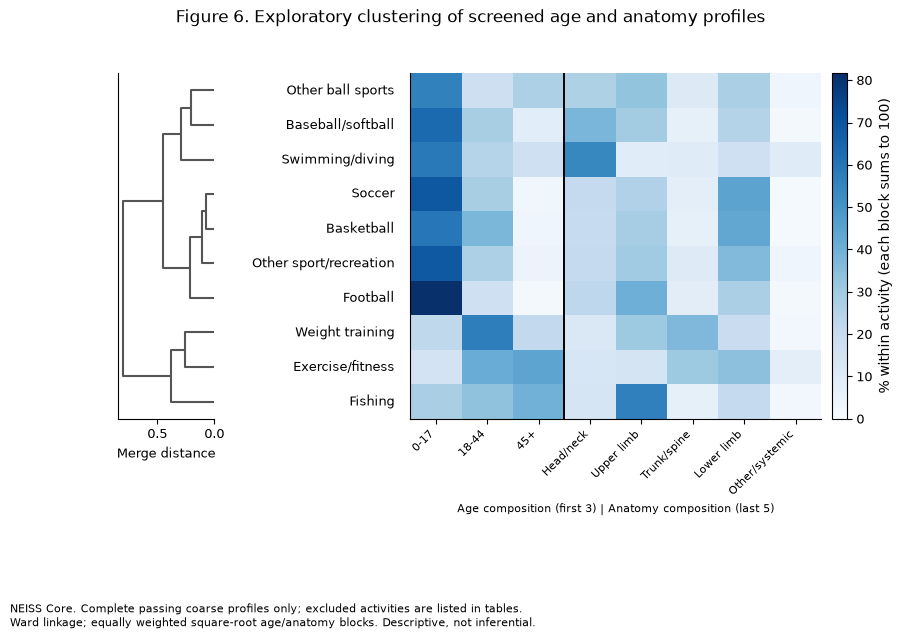

,included_activities,figure_created,pairwise_agreement,k
0,10,True,0.777778,4


In [15]:
cluster_ages = neiss.dictionary("cluster_age_bands").sort_values("lower")
if list(cluster_ages.upper.iloc[:-1]) != list(cluster_ages.lower.iloc[1:]):
    raise ValueError("Cluster age bands must be contiguous.")
cluster_age_edges = cluster_ages.lower.tolist() + [cluster_ages.upper.iloc[-1]]
cluster_age_labels = cluster_ages.label.tolist()
cluster_regions = neiss.dictionary("cluster_body_regions")
cluster_region_labels = list(dict.fromkeys(cluster_regions.cluster_region))
if cluster_regions.body_region.duplicated().any():
    raise ValueError("Duplicate coarse body-region mapping.")
if set(cluster_regions.body_region) != set(neiss.REGION_ORDER):
    raise ValueError("Coarse body-region map must cover the complete region dictionary.")

core["Cluster_Age"] = pd.cut(core.Age_Years, cluster_age_edges, labels=cluster_age_labels, right=False)
core["Cluster_Region"] = core.Body_Region.map(cluster_regions.set_index("body_region").cluster_region)
assert core[["Cluster_Age", "Cluster_Region"]].notna().all().all()
cluster_age, _ = summarise(core, ["Activity", "Cluster_Age"], "rq4_cluster_age",
    denominator=["Activity"], catalog=pd.MultiIndex.from_product(
        [ACTIVITIES, cluster_age_labels], names=["Activity", "Cluster_Age"]))
cluster_body, _ = summarise(core, ["Activity", "Cluster_Region"], "rq4_cluster_anatomy",
    denominator=["Activity"], catalog=pd.MultiIndex.from_product(
        [ACTIVITIES, cluster_region_labels], names=["Activity", "Cluster_Region"]))
age_ok = cluster_age.groupby("Activity", observed=True).reportable.all()
body_ok = cluster_body.groupby("Activity", observed=True).reportable.all()
eligible = sorted(set(age_ok.index[age_ok]) & set(body_ok.index[body_ok]))
cluster_selection = pd.DataFrame({
    "Activity": ACTIVITIES,
    "all_age_features_pass": [bool(age_ok.get(a, False)) for a in ACTIVITIES],
    "all_anatomy_features_pass": [bool(body_ok.get(a, False)) for a in ACTIVITIES],
    "included": [a in eligible for a in ACTIVITIES],
})
display(cluster_selection)
publish_table(cluster_selection, "rq4_cluster_selection")
cluster_status = {"included_activities": len(eligible), "figure_created": False}

if len(eligible) < 3:
    print("Clustering not produced: fewer than three complete reliable activity profiles.")
else:
    age_features = cluster_age.pivot(index="Activity", columns="Cluster_Age", values="percent").loc[
        eligible, cluster_age_labels] / 100
    body_features = cluster_body.pivot(index="Activity", columns="Cluster_Region", values="percent").loc[
        eligible, cluster_region_labels] / 100
    assert np.allclose(age_features.sum(axis=1), 1)
    assert np.allclose(body_features.sum(axis=1), 1)
    X = np.column_stack([np.sqrt(age_features)/np.sqrt(2), np.sqrt(body_features)/np.sqrt(2)])
    assert np.isfinite(X).all()
    ward = linkage(X, method="ward", metric="euclidean")
    average = linkage(X, method="average", metric="euclidean")
    k = min(4, len(eligible)-1)
    ward_labels = fcluster(ward, k, criterion="maxclust")
    average_labels = fcluster(average, k, criterion="maxclust")
    members = pd.DataFrame({"Activity": eligible, "ward_cluster": ward_labels,
                            "average_cluster": average_labels})
    publish_table(members, "rq4_cluster_membership")
    display(pd.crosstab(members.ward_cluster, members.average_cluster))
    agreement = neiss.pairwise_agreement(ward_labels, average_labels)
    print(f"Pairwise co-clustering agreement: {agreement:.3f}; k={k}")
    cluster_status.update({"figure_created": True, "pairwise_agreement": agreement, "k": k})

    features = pd.concat([age_features.add_prefix("Age "), body_features.add_prefix("Body ")], axis=1)*100
    fig = plt.figure(figsize=(9.4, max(6.4, len(eligible)*0.32+3.0)))
    grid = fig.add_gridspec(1, 4, width_ratios=[1.1, 2.0, 4.7, 0.17], wspace=0.06)
    tree_ax = fig.add_subplot(grid[0, 0])
    label_ax = fig.add_subplot(grid[0, 1])
    heat_ax = fig.add_subplot(grid[0, 2])
    colour_ax = fig.add_subplot(grid[0, 3])
    tree = dendrogram(ward, orientation="left", labels=eligible, ax=tree_ax,
                      color_threshold=0, above_threshold_color="#555555", no_labels=True)
    ordered = tree["ivl"][::-1]
    heat = features.loc[ordered]
    im = heat_ax.imshow(heat, cmap="Blues", aspect="auto", vmin=0, vmax=float(heat.max().max()))
    heat_ax.set_yticks([])
    label_ax.set_ylim(len(heat)-0.5, -0.5)
    label_ax.axis("off")
    for row, label in enumerate(heat.index):
        label_ax.text(0.97, row, label, ha="right", va="center", fontsize=9)
    # Put names between tree and heatmap with sufficient explicit padding.
    heat_ax.tick_params(axis="y", labelsize=9, pad=4)
    tree_ax.set_yticks([])
    tree_ax.set_xlabel("Merge distance", fontsize=9)
    heat_ax.set_xticks(range(len(heat.columns)), [c.replace("Age ", "").replace("Body ", "") for c in heat.columns], rotation=45, ha="right", fontsize=8)
    heat_ax.axvline(len(cluster_age_labels)-0.5, color="black", lw=1.4)
    fig.colorbar(im, cax=colour_ax, label="% within activity (each block sums to 100)")
    # Align identical leaf centres: scipy uses 5, 15, 25... from the bottom.
    tree_ax.set_ylim(0, 10*len(ordered))
    heat_ax.set_ylim(len(ordered)-0.5, -0.5)
    fig.suptitle("Figure 6. Exploratory clustering of screened age and anatomy profiles")
    # Space reserved for labels; colour bar is a separate axis.
    heat_ax.set_xlabel("Age composition (first 3) | Anatomy composition (last 5)", fontsize=8)
    save_figure(fig, "figure_06_activity_clusters.png",
        "NEISS Core. Complete passing coarse profiles only; excluded activities are listed in tables.\n"
        "Ward linkage; equally weighted square-root age/anatomy blocks. Descriptive, not inferential.", bottom=0.34)
publish_table(pd.DataFrame([cluster_status]), "rq4_cluster_status")


**What the results show.** Ten activities pass all feature checks and five are excluded. Ward and average linkage agree on 77.8% of activity-pair grouping decisions for the displayed four-group solutions. This shows that the grouping depends partly on the method; it is not a confidence score.

Age and anatomy are separate marginal summaries here. Similar marginals do not show that the same age groups sustain the same body-region injuries within each activity. The joint activity-age-anatomy screen is assessed separately. Two activities can also appear similar because their recorded patients have similar ages rather than because the activities have similar injury mechanisms. Evidence: `tables/rq4_cluster_status.csv`, `tables/rq4_cluster_membership.csv` and `tables/rq4_joint_cell_coverage.csv`.

Fishing forms a one-activity group under both Ward and average linkage at the selected four-group cut. That finding is conditional on the features, scaling, included activities and number of groups. It neither proves nor disproves that fishing belongs in Core. Eligibility follows the declared sport/recreation definition; clustering describes the presentations after that definition has been applied.

### 4.6  RQ5: Care outcomes across age groups

The recorded disposition indicates what happened after the emergency-department visit. The code compares release after treatment (code 1) with transfer, admission, observation or death in the ED (codes 2, 4, 5 and 8). The term “escalation” is the project’s label for that combined category, not a clinical severity score.

Only those five codes enter the denominator. Records outside them are excluded from this care-outcome calculation, while remaining available for other questions when otherwise eligible. The code also displays the individual outcome components to show what lies behind the combined measure.

Classification uses numerical codes. A historical version matched the word “TREATED” in the labels, which incorrectly placed admitted and transferred patients with released patients. Checking the explicit code sets prevents that particular error from recurring.

**Method.** The code separates patients released after treatment from those transferred, admitted, observed or recorded as fatalities. It compares these outcomes by age, excluding records without an eligible care outcome; these outcomes do not directly measure injury severity.


Excluded from care-outcome denominator: 9701


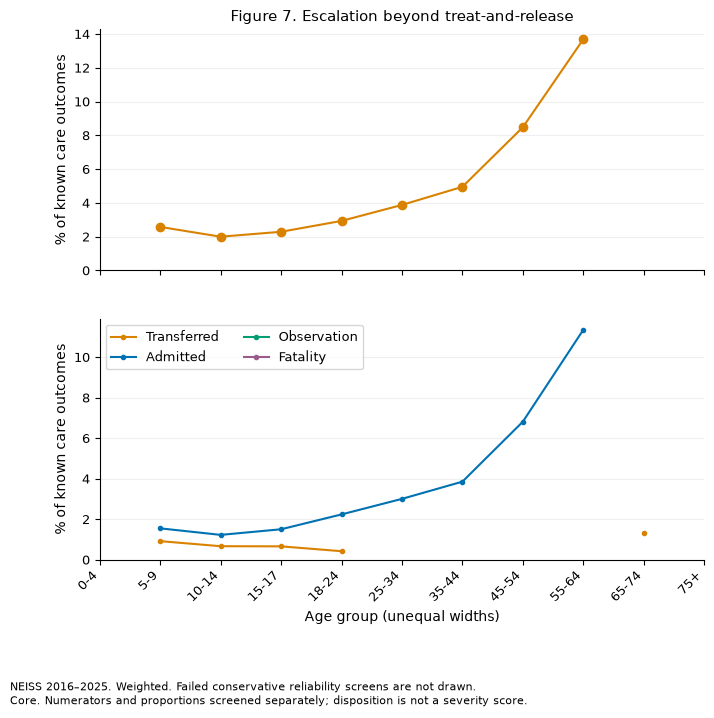

,Age_Band,n,estimate_rounded,percent,percent_cv_bound,reportable,reason
11,0-4,1395,NaN,NaN,0.176244,False,"CV bound outside [0, 0.33]"
12,5-9,2352,4900.0,2.6,0.141336,True,passes conservative screen
13,10-14,5509,11300.0,2.0,0.123498,True,passes conservative screen
14,15-17,3432,9100.0,2.3,0.119288,True,passes conservative screen
15,18-24,2437,9300.0,2.9,0.115108,True,passes conservative screen
16,25-34,2371,9500.0,3.9,0.115606,True,passes conservative screen
17,35-44,1918,8200.0,5.0,0.134302,True,passes conservative screen
18,45-54,2200,10100.0,8.5,0.149166,True,passes conservative screen
19,55-64,2914,13900.0,13.7,0.159556,True,passes conservative screen
20,65-74,3764,NaN,NaN,0.173896,False,"CV bound outside [0, 0.33]"


In [16]:
care = core.loc[core.Disposition.isin(neiss.RELEASED | neiss.ESCALATED)].copy()
care["Care_Outcome"] = np.where(care.Disposition.isin(neiss.ESCALATED), "Escalated", "Released")
print("Excluded from care-outcome denominator:", len(core)-len(care))
outcome_catalog = pd.MultiIndex.from_product(
    [["Released", "Escalated"], neiss.AGE_LABELS], names=["Care_Outcome", "Age_Band"])
care_summary, _ = summarise(care, ["Care_Outcome", "Age_Band"], "rq5_care_outcome",
                            denominator=["Age_Band"], catalog=outcome_catalog)
disp_names = neiss.dictionary("dispositions").set_index("code").official_label
component_order = [disp_names.loc[c] for c in [1, 2, 4, 5, 8]]
component_catalog = pd.MultiIndex.from_product(
    [component_order, neiss.AGE_LABELS], names=["Disposition_Label", "Age_Band"])
components, _ = summarise(care, ["Disposition_Label", "Age_Band"], "rq5_components",
                          denominator=["Age_Band"], catalog=component_catalog)
escalation = care_summary.loc[care_summary.Care_Outcome.eq("Escalated")].set_index("Age_Band").reindex(neiss.AGE_LABELS)
xs = np.arange(len(neiss.AGE_LABELS))
fig, axes = plt.subplots(2, 1, figsize=(7.8, 7.8), sharex=True)
axes[0].plot(xs, safe_values(escalation, "percent"), color=ORANGE, marker="o")
axes[0].set_title("Figure 7. Escalation beyond treat-and-release")
axes[0].set_ylabel("% of known care outcomes")
short_names = {2: "Transferred", 4: "Admitted", 5: "Observation", 8: "Fatality"}
for code_value, colour in zip([2, 4, 5, 8], COLOURS):
    name = disp_names.loc[code_value]
    t = components.loc[components.Disposition_Label.eq(name)].set_index("Age_Band").reindex(neiss.AGE_LABELS)
    axes[1].plot(xs, safe_values(t, "percent"), color=colour, marker=".", label=short_names[code_value])
axes[1].set_ylabel("% of known care outcomes")
axes[1].set_xlabel("Age group (unequal widths)")
axes[1].set_xticks(xs, neiss.AGE_LABELS, rotation=45, ha="right")
axes[1].legend(ncol=2, fontsize=9)
for ax in axes:
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.2)
save_figure(fig, "figure_07_disposition.png", SCREEN_NOTE + "\nCore. Numerators and proportions screened separately; disposition is not a severity score.")
display(neiss.report_table(care_summary).loc[lambda x: x.Care_Outcome.eq("Escalated"),
    ["Age_Band", "n", "estimate_rounded", "percent", "percent_cv_bound", "reportable", "reason"]])

**What the results show.** This calculation excludes 9,701 Core records outside the eligible outcome codes. Among passing age groups, the escalation percentage is 2.0% at ages 10–14 and 13.7% at ages 55–64. The values at 0–4, 65–74 and 75+ fail the combined display rule because their estimated-total CV exceeds 0.33, although their proportion CV passes. Their sample counts exceed 20; this is not failure of the minimum sample-count threshold.

Disposition may reflect admission practice and other clinical circumstances as well as the injury. It cannot, by itself, establish that injuries are more severe in one age group. Evidence: `tables/rq5_care_outcome.csv` and `tables/rq5_components.csv`.

**A limitation of masking complementary outcomes.** Released and escalated exhaust the eligible denominator. The published released shares of 92.7%, 78.9% and 70.4% therefore reveal approximate escalation shares of 7.3%, 21.1% and 29.6% by subtraction. These reconstructed percentages are approximate because the published shares are rounded. The rule withholds the direct escalation display; it does not make the value unrecoverable.

For ages 0–4, 65–74 and 75+, the estimated-total CV bounds are approximately 0.363, 0.355 and 0.354, while the proportion CV bounds are 0.176, 0.174 and 0.134. The chosen rule requires both checks to pass. That is stricter than a proportion-only rule. The underlying point estimates suggest a U-shaped age pattern, but point-estimate shape alone does not establish its statistical robustness. This limitation is acknowledged without changing the prespecified display rule or presenting the reconstructed values as newly passing estimates.

## 5  How dependent are the findings on analytical choices?

The following checks vary the cohort, product attribution, years or weighting method. They compare results only where both versions pass the display rule. A small maximum difference on that shared set says nothing about combinations that could not be compared.

Differences in composition are measured in percentage points (pp): for example, a change from 10% to 12% is 2 percentage points. This is different from a 20% relative increase. The output reports both the maximum absolute difference and the coverage of the comparison.

**Method.** The code repeats the summaries with different cohort definitions, year selections and weighting choices. It measures how much the results change and records how many values can be compared, showing where conclusions depend on those choices.


In [17]:
METRICS = {
    "RQ1_age": (["Age_Display"], []),
    "RQ2_anatomy": (["Body_Region", "Age_Band"], ["Age_Band"]),
    "RQ3_diagnosis": (["Diagnosis_Plot", "Age_Band"], ["Age_Band"]),
    "RQ4_profiles": (["Activity", "Profile_Age"], ["Activity"]),
    "RQ5_disposition": (["Care_Outcome", "Age_Band"], ["Age_Band"]),
}
CATALOGS = {
    "RQ1_age": age_catalog, "RQ2_anatomy": bp_catalog, "RQ3_diagnosis": dg_catalog,
    "RQ4_profiles": profile_catalog, "RQ5_disposition": outcome_catalog,
}
BASELINE = {"RQ1_age": age_tables["Core"], "RQ2_anatomy": anatomy,
            "RQ3_diagnosis": diagnosis, "RQ4_profiles": profiles, "RQ5_disposition": care_summary}

def metric_frame(frame, metric):
    if metric == "RQ5_disposition":
        frame = frame.loc[frame.Disposition.isin(neiss.RELEASED | neiss.ESCALATED)].copy()
        frame["Care_Outcome"] = np.where(frame.Disposition.isin(neiss.ESCALATED),
                                         "Escalated", "Released")
    return frame

def compare_tables(base, alternative, keys, value, scenario, metric):
    columns = keys + [value, "reportable"]
    merged = base[columns].merge(alternative[columns], on=keys, how="outer",
                                 suffixes=("_base", "_alternative"))
    common = (merged.reportable_base.eq(True) & merged.reportable_alternative.eq(True)
              & merged[f"{value}_base"].notna() & merged[f"{value}_alternative"].notna())
    delta = (merged.loc[common, f"{value}_alternative"] - merged.loc[common, f"{value}_base"]).abs()
    return {
        "scenario": scenario, "metric": metric, "value": value,
        "units": "percentage points" if value == "percent" else "average annual presentations",
        "cells_compared": int(common.sum()), "cells_in_union": len(merged),
        "coverage_percent": 100*common.mean() if len(merged) else 0,
        "max_absolute_change": delta.max(), "mean_absolute_change": delta.mean(),
    }

sensitivity_rows = []
SCENARIOS = [
    ("Extended", extended, YEARS),
    ("Core_P1_only", core.loc[core.Product_1.isin(core_codes)], YEARS),
    ("Core_without_2020", core.loc[core.Source_Year.ne(2020)], [y for y in YEARS if y != 2020]),
    ("Core_2016_2023", core.loc[core.Source_Year.le(2023)], list(range(2016, 2024))),
]
for scenario, frame, year_subset in SCENARIOS:
    print("Sensitivity:", scenario)
    for metric, (keys, den) in METRICS.items():
        t, _ = neiss.domain_summary(metric_frame(frame, metric), roster, keys,
            denominator=den, catalog=CATALOGS[metric], years=year_subset)
        publish_table(t, f"sensitivity_{scenario}_{metric}")
        sensitivity_rows.append(compare_tables(BASELINE[metric], t, keys, "percent", scenario, metric))
        if metric == "RQ1_age":
            sensitivity_rows.append(compare_tables(BASELINE[metric], t, keys, "estimate", scenario, metric))

# Unweighted percentages describe sample composition; national estimate thresholds do
# not apply to a sample count treated as though it were a national weighted estimate.
for metric, (keys, den) in METRICS.items():
    frame = metric_frame(core, metric)
    counts = frame.groupby(keys, observed=True).size().reindex(CATALOGS[metric], fill_value=0)
    unweighted = counts.rename("n").reset_index()
    if den:
        totals = frame.groupby(den, observed=True).size().rename("denominator_n").reset_index()
        unweighted = unweighted.merge(totals, on=den, how="left")
    else:
        unweighted["denominator_n"] = len(frame)
    unweighted["percent"] = 100*unweighted.n/unweighted.denominator_n
    unweighted["reportable"] = unweighted.n.ge(20) & unweighted.percent.notna()
    unweighted["reason"] = np.where(unweighted.reportable,
        "sample descriptive percentage; n >=20", "sample n <20 or no denominator")
    publish_table(unweighted, f"sensitivity_unweighted_{metric}")
    sensitivity_rows.append(compare_tables(BASELINE[metric], unweighted, keys,
        "percent", "Unweighted_sample_vs_weighted", metric))

# Equal-year means: include a comparison only when every year's percentage passes
# the annual working screen, so missing years do not silently alter the estimand.
for metric, (keys, den) in METRICS.items():
    yearly = []
    frame = metric_frame(core, metric)
    for year in YEARS:
        t, _ = neiss.domain_summary(frame, roster, keys, denominator=den,
                                   catalog=CATALOGS[metric], years=[year])
        t["Source_Year"] = year
        yearly.append(t)
    annual_percent = pd.concat(yearly, ignore_index=True)
    mean_percent = annual_percent.groupby(keys, observed=True).agg(
        percent=("percent", "mean"), reportable=("reportable", "all"),
        observed_years=("Source_Year", "nunique")).reset_index()
    mean_percent.reportable &= mean_percent.observed_years.eq(len(YEARS))
    mean_percent["reason"] = np.where(mean_percent.reportable,
        "all annual percentages pass", "at least one annual percentage fails")
    publish_table(mean_percent, f"sensitivity_equal_year_{metric}")
    sensitivity_rows.append(compare_tables(BASELINE[metric], mean_percent, keys,
        "percent", "Equal_year_mean_vs_pooled", metric))

sensitivity = pd.DataFrame(sensitivity_rows)
publish_table(sensitivity, "sensitivity_summary")
display(sensitivity.round(3))


Sensitivity: Extended


Sensitivity: Core_P1_only


Sensitivity: Core_without_2020


Sensitivity: Core_2016_2023


,scenario,metric,value,units,cells_compared,cells_in_union,coverage_percent,max_absolute_change,mean_absolute_change
0,Extended,RQ1_age,percent,percentage points,91,91,100.000,1.343,0.193
1,Extended,RQ1_age,estimate,average annual presentations,91,91,100.000,49466.003,11714.683
2,Extended,RQ2_anatomy,percent,percentage points,126,154,81.818,6.708,0.888
3,Extended,RQ3_diagnosis,percent,percentage points,65,66,98.485,17.805,3.305
4,Extended,RQ4_profiles,percent,percentage points,163,255,63.922,1.777,0.043
5,Extended,RQ5_disposition,percent,percentage points,19,22,86.364,3.083,1.610
6,Core_P1_only,RQ1_age,percent,percentage points,91,91,100.000,0.053,0.007
7,Core_P1_only,RQ1_age,estimate,average annual presentations,91,91,100.000,2024.653,480.926
8,Core_P1_only,RQ2_anatomy,percent,percentage points,126,154,81.818,0.387,0.053
9,Core_P1_only,RQ3_diagnosis,percent,percentage points,65,66,98.485,0.577,0.137


### Observed sensitivity results

Six sensitivity checks assess how analytical choices affect the displayed results.

|  | Check | Result |
| --- | --- | --- |
| A | Extended versus Core | Maximum diagnosis shift 17.81 pp; 65/66 cells compared |
| B | Product 1 only | Maximum diagnosis shift 0.58 pp; 65/66 cells compared |
| C | Exclude 2020 | Maximum diagnosis shift 0.59 pp; 65/66 cells compared |
| D | 2016–2023 versus 2016–2025 | Maximum diagnosis shift 1.76 pp; 65/66 cells compared |
| E | Unweighted versus weighted | Maximum activity-age shift 6.37 pp; 163/255 cells compared |
| F | Equal-year mean versus pooled | Maximum activity-age shift 0.58 pp; 121/255 cells compared |

The 2024 sample change affects cross-year comparison (Schroeder, 2026). A common multiplier cancels from a proportion; changes in relative hospital weights do not. Check D examines excluding the refreshed years, while E compares weighting choices. Neither isolates reweighting causally. Check A assesses cohort definition, a separate issue.

Equal-year means give each year equal influence; pooled proportions give larger estimated denominators more influence. Check F compares only 121/255 cells, limiting claims of small differences.

**Why the cohort boundary matters.** The largest diagnosis difference is in “All other diagnoses” at ages 0–4: 47.5% in Core versus 29.7% in Extended. The sensitivity calculation uses unrounded values and reports 17.81 percentage points. Fracture in the same age group changes from 7.8% to 20.3%. These figures show that the selected product categories materially affect the clinical composition being described.

The comparison adds several recreational categories simultaneously. It does not identify how much cycling, playground equipment or any other category contributes separately. Because percentages are calculated within each age band, merely adding more children across the whole cohort cannot explain this difference: the diagnosis mix within the age band must differ. The choice of Core remains a scope decision, and Extended shows how much that choice can matter. Evidence: `tables/rq3_diagnosis.csv`, `tables/sensitivity_Extended_RQ3_diagnosis.csv` and `tables/sensitivity_summary.csv`.

### Comparing activity groups across time windows

The code repeats the activity grouping using data through 2023 and compares it with the full period. Only activities with usable values in both periods are compared, so agreement is limited to that shared set.


In [18]:
if cluster_status["figure_created"]:
    earlier = core.loc[core.Source_Year.le(2023)]
    earlier_age, _ = neiss.domain_summary(earlier, roster, ["Activity", "Cluster_Age"],
        denominator=["Activity"], catalog=pd.MultiIndex.from_product(
            [eligible, cluster_age_labels], names=["Activity", "Cluster_Age"]),
        years=list(range(2016, 2024)))
    earlier_body, _ = neiss.domain_summary(earlier, roster, ["Activity", "Cluster_Region"],
        denominator=["Activity"], catalog=pd.MultiIndex.from_product(
            [eligible, cluster_region_labels], names=["Activity", "Cluster_Region"]),
        years=list(range(2016, 2024)))
    a_pass = earlier_age.groupby("Activity", observed=True).reportable.all()
    b_pass = earlier_body.groupby("Activity", observed=True).reportable.all()
    common = sorted(set(eligible) & set(a_pass.index[a_pass]) & set(b_pass.index[b_pass]))
    print(f"Common complete profiles for clustering-window comparison: {len(common)}")
    if len(common) >= 3:
        e_age = earlier_age.pivot(index="Activity", columns="Cluster_Age", values="percent").loc[
            common, cluster_age_labels]/100
        e_body = earlier_body.pivot(index="Activity", columns="Cluster_Region", values="percent").loc[
            common, cluster_region_labels]/100
        x_early = np.column_stack([np.sqrt(e_age)/np.sqrt(2), np.sqrt(e_body)/np.sqrt(2)])
        x_full = np.column_stack([np.sqrt(age_features.loc[common])/np.sqrt(2),
                                  np.sqrt(body_features.loc[common])/np.sqrt(2)])
        comparison_k = min(4, len(common)-1)
        ids_early = fcluster(linkage(x_early, method="ward"), comparison_k, criterion="maxclust")
        ids_full = fcluster(linkage(x_full, method="ward"), comparison_k, criterion="maxclust")
        window_clusters = pd.DataFrame({"Activity": common, "full_window": ids_full,
                                         "through_2023": ids_early})
        publish_table(window_clusters, "sensitivity_clustering_window")
        display(pd.crosstab(window_clusters.full_window, window_clusters.through_2023))
        print("Pairwise agreement:", neiss.pairwise_agreement(ids_full, ids_early))
    else:
        print("Insufficient common profiles: do not claim cross-window clustering stability.")
else:
    print("Clustering sensitivity not applicable because no reliable main clustering was produced.")


Common complete profiles for clustering-window comparison: 9


through_2023,1,2,3,4
full_window,,,,
1,2,0,0,0
2,0,1,0,0
3,0,0,5,0
4,0,0,0,1


Pairwise agreement: 1.0


**Time-window comparison.** The full-window and through-2023 grouping solutions agree on the nine activities that pass in both windows. This is agreement within a selected common set, not evidence that all activities have stable patterns. The comparison changes both the years and the available passing activities; it does not isolate the causal effect of the sample refresh. Evidence: `tables/sensitivity_clustering_window.csv`.

### Analysis record

Software versions, study years, cohort sizes and generated figures are saved with this run.

In [19]:
runtime_record = {
    "versions": VERSIONS,
    "pipeline_version": neiss.PIPELINE_VERSION,
    "study_years": YEARS,
    "core_n": int(len(core)),
    "extended_n": int(len(extended)),
    "figures_written_this_run": WRITTEN_FIGURES,
    "clustering": cluster_status,
}
(PROJECT_ROOT / "tables/run_record.json").write_text(
    json.dumps(runtime_record, indent=2), encoding="utf-8"
)


815

## 6  Critical engagement with AI

AI assistance was used for code drafting, dataset auditing and prose editing. ChatGPT subsequently rebuilt and executed the corrected analysis with permission; assistant checks are distinguished from personal verification. Two examples were errors that reached a figure, and they were the same error twice.

The body-region and diagnosis-family mappings were originally produced by typing NEISS code numbers rather than joining to the official labels, and diagnosis codes 62 and 64 were transposed. The resulting diagnosis distribution was wrong despite plausible-looking code. The historical log records the error and correction; the current helper verifies code-label joins.

The same failure mode then recurred in section 4.6, classifying disposition by matching a text prefix instead of the code. Both illustrate why a plausible label match is insufficient. Current assertions check mappings and attribution, and analyst-defined groupings remain reviewable CSVs. These checks catch specified failures, not every possible error.

The general lesson is that AI output which is plausible in form can be wrong in content. Both source verification and numerical checks are needed; neither code review nor output plausibility alone establishes correctness.

## 7  Conclusions and evaluation

### 7.1  What the figures show

**RQ1**: Core presentations peak at 14 and fall approximately nine times by 40, and male and female peaks occur at 15 and 14 respectively.

**RQ2**: Head and face account for 52% before age five and 13% at 45–54, and trunk and spine rise from 6% at 5–9 to 32% at 75+.

**RQ3**: Strain and sprain become less prominent after mid-life, while fracture and internal injury become more prominent.

**RQ4**: Activities have distinct age profiles, and their mixture shapes the overall curve.

**RQ5**: Escalation rises across supported adolescent and adult groups, but suppression prevents conclusions about the oldest groups.

### 7.2  What the figures cannot show

No rate, risk or incidence appears anywhere, because NEISS has no participation denominator. The declining totals after adolescence could reflect fewer participants, different injury occurrence, different activities or use of other care settings. These data do not establish which explanation dominates. Product association is not participation. Disposition depends on admission practice as well as injury characteristics; it is neither a severity score nor a quantified bound on severity differences.

### 7.3  Evaluation of the visualisation choices

Normalising within age band, in Figures 3 and 4, is what makes childhood and old age comparable when the volumes differ by an order of magnitude. It also lets a thin age band look important, so every such figure carries the raw case count through the declared working screen and suppresses what fails it.

Trajectories rather than a second heatmap for RQ3 keeps the two figures doing different work, while a second heatmap would remain a defensible alternative. Small multiples kept fifteen activity profiles readable, and alphabetical ordering helps lookup but does not reveal an age ordering. Shared scales support comparison while suppression limits coverage.

A future extension could examine Location, which is recorded throughout the study window but was not analysed here. Its unknown codes and suitability for each question would first need checking. The clustering adds a descriptive comparison, but its choices and excluded activities limit how strongly it can be interpreted. Further improvements include official survey-variance implementation and alternative clinical groupings. Only 396/2,310 joint activity-age-anatomy cells pass: adequate marginal profiles do not establish adequate joint coverage.

## References

Consumer Product Safety Commission (2020) NEISS Coding Manual, January 2020. Available at: https://www.cpsc.gov/s3fs-public/2020-CPSC-Only-Non-Trauma-Coding-Manual.pdf (Accessed: 1 September 2026).

Consumer Product Safety Commission (n.d.a) National Electronic Injury Surveillance System public-use data [annual files, treatment years 2016–2025]. Available at: https://www.cpsc.gov/cgibin/NEISSQuery/home.aspx (Accessed: 1 September 2026).

Schroeder, T. (2026) Consumer Product-Related Injuries and Deaths in the United States: Estimated Injuries Occurring in 2024 and Estimated Deaths Occurring in 2023. Consumer Product Safety Commission, April, p. 7. Available at: https://www.cpsc.gov/s3fs-public/Death_and_Injury_Report_2024.pdf (Accessed: 1 September 2026).

Heer, J., Bostock, M. and Ogievetsky, V. (2010) A tour through the visualization zoo. Communications of the ACM, 53(6), pp. 59–67. Available at: https://idl.uw.edu/papers/visualization-zoo (Accessed: 1 September 2026).

Consumer Product Safety Commission (n.d.b) Explanation of NEISS estimates obtained through the CPSC website. Available at: https://www.cpsc.gov/Research--Statistics/NEISS-Injury-Data/Explanation-Of-NEISS-Estimates-Obtained-Through-The-CPSC-Website (Accessed: 1 September 2026).

SciPy (n.d.) scipy.cluster.hierarchy.linkage. Available at: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html (Accessed: 1 September 2026).

Consumer Product Safety Commission (2025) NEISS Coding Manual, January 2025 (rev. 1), p. 10. Available at: https://www.cpsc.gov/s3fs-public/JANUARY-2025-NEISS-CPSC-only-Coding-Manual-Rev-1.pdf (Accessed: 1 September 2026).

Rui, P., Ashman, J.J. and Akinseye, A. (2019) Emergency department visits for injuries sustained during sports and recreational activities by patients aged 5–24 years, 2010–2016. National Health Statistics Reports, 133. Available at: https://www.cdc.gov/nchs/data/nhsr/nhsr133-508.pdf (Accessed: 1 September 2026).

Wickham, H. (2014) Tidy data. Journal of Statistical Software, 59(10), pp. 1–23. https://doi.org/10.18637/jss.v059.i10 (Accessed: 1 September 2026).

Wilke, C.O. (2019) Fundamentals of Data Visualization. O’Reilly Media, chapter 21. Available at: https://clauswilke.com/dataviz/multi-panel-figures.html (Accessed: 1 September 2026).